# Water Network Leak Detection — Time-Aware Classification
### A beginner-friendly, time-aware classification project

**How to read this notebook:** every section answers four questions — *where am I → what am I learning → why am I doing it → what does the result mean.*

**Workflow:** Understand → Explore → Prepare → Prevent Leakage → Split → Train → Evaluate → Tune → Interpret → Conclude

| # | Section | # | Section |
|---|---|---|---|
| 1 | Project Introduction | 14 | Why Accuracy Can Be Misleading |
| 2 | Load and Understand the Data | 15 | Time-Series Cross-Validation |
| 3 | Data Quality | 16 | Hyperparameters and GridSearchCV |
| 4 | Exploratory Data Analysis | 17 | Model Comparison |
| 5 | Understand the Target | 18 | Final Model and Untouched Test |
| 6 | Date and Time Understanding | 19 | Confusion Matrix |
| 7 | Feature Preparation | 20 | ROC and Precision-Recall Curves |
| 8 | Data Leakage | 21 | Error Analysis |
| 9 | Chronological Train / Validation / Test Split | 22 | Feature Importance |
| 10 | Preprocessing | 23 | Model Reality Check |
| 11 | Classification Baseline | 24 | Risk Analysis |
| 12 | Classification Models | 25 | Limitations |
| 13 | Classification Metrics | 26 | Final Conclusion |

---
# Section 1 — Project Introduction

### What is this project?
A small machine-learning project that learns to **classify** hourly records from a water network into two groups (explained below). It is a *learning project*: the goal is to learn classification, time-aware evaluation and honest interpretation — not to build a product.

### What is the water-network problem?
A city water network loses water through **leaks** in its pipes. Utilities collect sensor data (pumping-station energy use, water-source sensors, groundwater and temperature readings) and record confirmed leak events in a maintenance system. The hope is that sensor readings behave *unusually* around leak events.

### What is the dataset?
*Hourly Anomaly Scores and Leak Labels from a Multi-Source Urban Water Distribution Network* (Zenodo, DOI `10.5281/zenodo.15096167`, licence CC BY 4.0).
- One row per **hour**, from the end of December 2021 to the end of December 2022 (8,737 rows).
- 18 **anomaly scores** from 0 to 100 (higher = more unusual than normal). They were produced by the dataset authors with anomaly-detection algorithms; they are not raw sensor readings.
- One label column, `fault_d7`.

### What does `fault_d7` represent?
`fault_d7 = 1` means the hour lies **within about ±7 days (before or after) of a recorded leak event**. `fault_d7 = 0` means no recorded leak event within that window.

> ⚠️ **Important:** this is a **leak-proximity** label. It is *not* "a leak is happening right now", and the window includes days *after* an event. So this project is **not a real-time leak detector** and not an early-warning system.

### Why is this a classification problem?
The answer we want is a **category** (0 or 1), not a number. Predicting a category = **classification**. With two categories it is **binary classification**.

### What are we trying to predict?
For each hourly row: *does this hour fall inside a leak-proximity window (1) or not (0)?* — using only that hour's anomaly scores and its time of day / day of week.

### Basic workflow
**Understand → Explore → Prepare → Prevent Leakage → Split → Train → Evaluate → Tune → Interpret → Conclude**

---
# Section 2 — Load and Understand the Data

**What we learn here:** what the data looks like.  **Why:** you cannot model data you do not understand.

We import only what we need now. Scikit-learn tools are imported later, right where we first use them.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   # used only for heatmaps

os.makedirs("figures", exist_ok=True)   # folder where charts are saved

In [2]:
df = pd.read_csv("../03_Data/Water_Network_Leak_Detection.csv")
df.head()

,timestamp,fault_d7,4700008966_kW,4700008966_power_hour,4408411600_kW,4408411600_power_hour,4608927500_kvar_hour,238045_ws_temp,279805_ws_vigor,279804_ws_level,279625_ws_temp,279623_ws_vigor,319235_ws_temp,279831_ws_temp,326417_ws_temp,326416_ws_vigor,temp_site1_anomaly_score,sfc_temp_site1_anomaly_score,gw_lvl_site2_anomaly_score,gw_temp_site2_anomaly_score
0,31-12-2021 23:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-01-2022 0:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.34,7.63,9.48,38.44
2,01-01-2022 1:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.96,0.87,9.48,38.44
3,01-01-2022 2:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.01,1.23,9.48,38.44
4,01-01-2022 3:00,0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.51,4.86,9.48,38.44


In [3]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (8737, 20)


In [4]:
print(list(df.columns))

['timestamp', 'fault_d7', '4700008966_kW', '4700008966_power_hour', '4408411600_kW', '4408411600_power_hour', '4608927500_kvar_hour', '238045_ws_temp', '279805_ws_vigor', '279804_ws_level', '279625_ws_temp', '279623_ws_vigor', '319235_ws_temp', '279831_ws_temp', '326417_ws_temp', '326416_ws_vigor', 'temp_site1_anomaly_score', 'sfc_temp_site1_anomaly_score', 'gw_lvl_site2_anomaly_score', 'gw_temp_site2_anomaly_score']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8737 entries, 0 to 8736
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   timestamp                     8737 non-null   str    
 1   fault_d7                      8737 non-null   int64  
 2   4700008966_kW                 8737 non-null   float64
 3   4700008966_power_hour         8737 non-null   float64
 4   4408411600_kW                 6578 non-null   float64
 5   4408411600_power_hour         6578 non-null   float64
 6   4608927500_kvar_hour          8737 non-null   float64
 7   238045_ws_temp                8737 non-null   float64
 8   279805_ws_vigor               8724 non-null   float64
 9   279804_ws_level               8724 non-null   float64
 10  279625_ws_temp                8256 non-null   float64
 11  279623_ws_vigor               8256 non-null   float64
 12  319235_ws_temp                8700 non-null   float64
 13  279831_ws_temp

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fault_d7,8737.0,0.74,0.44,0.0,0.00,1.00,1.00,1.00
4700008966_kW,8737.0,1.24,8.65,0.0,0.00,0.00,0.00,99.08
4700008966_power_hour,8737.0,1.23,8.62,0.0,0.00,0.00,0.00,99.08
4408411600_kW,6578.0,0.19,3.12,0.0,0.00,0.00,0.00,94.84
4408411600_power_hour,6578.0,0.33,4.29,0.0,0.00,0.00,0.00,97.25
4608927500_kvar_hour,8737.0,0.50,5.71,0.0,0.00,0.00,0.00,99.01
238045_ws_temp,8737.0,0.11,2.18,0.0,0.00,0.00,0.00,95.76
279805_ws_vigor,8724.0,0.87,6.22,0.0,0.00,0.00,0.00,91.96
279804_ws_level,8724.0,0.37,4.79,0.0,0.00,0.00,0.00,85.69
279625_ws_temp,8256.0,0.28,3.46,0.0,0.00,0.00,0.00,67.27


### The target column and the feature columns

- **Target:** `fault_d7` (0 or 1) — what we want to predict.
- **Time column:** `timestamp` — when the hour happened (stored as text, `day-month-year hour:00`).
- **Features:** the other 18 columns — anomaly scores (0–100). Their names follow `source_measurement`:

| Name pattern | Meaning |
|---|---|
| `..._kW`, `..._power_hour` | Anomaly scores of **energy use** at pumping stations |
| `..._ws_temp`, `..._ws_vigor`, `..._ws_level` | Anomaly scores of **water-source sensors** (temperature, "vigor" and level) |
| `temp_site1_...`, `sfc_temp_site1_...` | Anomaly scores of **air / surface temperature** at site 1 |
| `gw_lvl_site2_...`, `gw_temp_site2_...` | Anomaly scores of **groundwater level / temperature** at site 2 |

In [7]:
target = "fault_d7"
score_columns = [column for column in df.columns if column not in ["timestamp", target]]

print("Target:", target)
print("Number of anomaly-score features:", len(score_columns))
score_columns

Target: fault_d7
Number of anomaly-score features: 18


['4700008966_kW',
 '4700008966_power_hour',
 '4408411600_kW',
 '4408411600_power_hour',
 '4608927500_kvar_hour',
 '238045_ws_temp',
 '279805_ws_vigor',
 '279804_ws_level',
 '279625_ws_temp',
 '279623_ws_vigor',
 '319235_ws_temp',
 '279831_ws_temp',
 '326417_ws_temp',
 '326416_ws_vigor',
 'temp_site1_anomaly_score',
 'sfc_temp_site1_anomaly_score',
 'gw_lvl_site2_anomaly_score',
 'gw_temp_site2_anomaly_score']

**What we see:** 8,737 rows and 20 columns: `timestamp` (stored as text), `fault_d7` (the target) and 18 anomaly scores. Some scores have fewer than 8,737 values (for example `326416_ws_vigor` has only 4,470), so some sensors have missing data. Most scores have a median of 0 — they are zero most of the time and spike only occasionally. About 74% of rows have `fault_d7 = 1`.

**What it means:** we must (1) convert `timestamp` into a real date — which, as Section 3 shows, needs care —, (2) deal with missing values, and (3) remember that class 1 is the *majority* class, which will matter a lot for evaluation.

---
# Section 3 — Data Quality

**What we learn here:** can we trust the data?  **Why:** bad data → bad model.

We check: missing values, duplicate rows, duplicate timestamps, data types, unusual values and class labels.

### 3.1 Missing values

In [8]:
print("Total missing cells:", df.isnull().sum().sum())
print("Rows with at least one missing value:", df.isnull().any(axis=1).sum(), "of", len(df))

Total missing cells: 16804
Rows with at least one missing value: 5707 of 8737


In [9]:
missing_percent = (df[score_columns].isnull().mean() * 100).sort_values()
missing_percent[missing_percent > 0].round(1)

sfc_temp_site1_anomaly_score     0.0
temp_site1_anomaly_score         0.0
279805_ws_vigor                  0.1
279804_ws_level                  0.1
319235_ws_temp                   0.4
279831_ws_temp                   0.5
279625_ws_temp                   5.5
279623_ws_vigor                  5.5
gw_temp_site2_anomaly_score     16.5
gw_lvl_site2_anomaly_score      16.5
4408411600_kW                   24.7
4408411600_power_hour           24.7
326417_ws_temp                  48.8
326416_ws_vigor                 48.8
dtype: float64

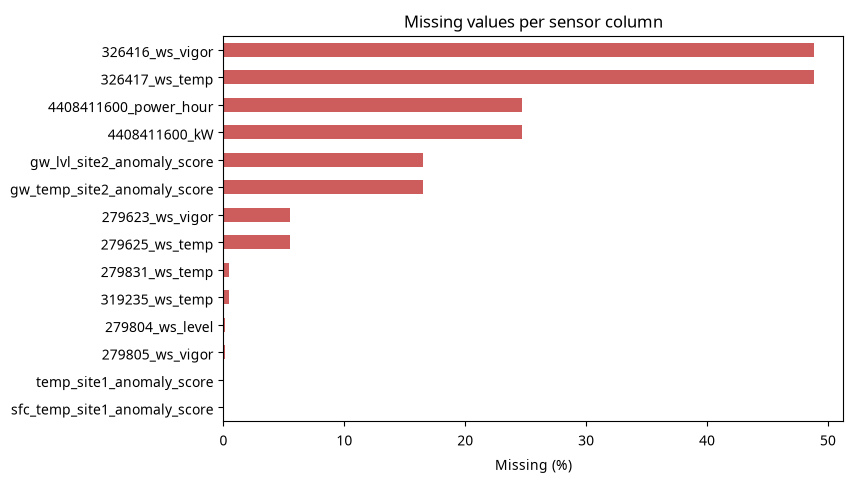

In [10]:
plt.figure(figsize=(8, 5))
missing_percent[missing_percent > 0].plot(kind="barh", color="indianred")
plt.title("Missing values per sensor column")
plt.xlabel("Missing (%)")
plt.savefig("../04_Figures/01_missing_values.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** 16,804 missing cells, and 5,707 of the 8,737 rows (65%) have at least one missing score. Missing values sit in 14 of the 18 score columns. The worst are two water-source sensors (`326416_ws_vigor`, `326417_ws_temp`, about 49% missing), a pumping-station energy sensor (`4408411600_*`, about 25%) and the two groundwater scores (about 16.5%).

### 3.2 Duplicates

In [11]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

Duplicate rows: 0
Duplicate timestamps: 0


### 3.3 Data types and time order
The `timestamp` column is text, so we must turn it into a real date-time. The documentation says the format is `day-month-year`. Let us try exactly that — and check whether the rows are in time order. They should be: the file is a continuous hourly record.

In [12]:
raw_timestamp = df["timestamp"].copy()        # keep the original text

documented = pd.to_datetime(raw_timestamp, format="%d-%m-%Y %H:%M")

print("Rows in time order?", documented.is_monotonic_increasing)
print("Times the clock jumps backwards:", (documented.diff() < pd.Timedelta(0)).sum())

Rows in time order? False
Times the clock jumps backwards: 22


A clock that jumps backwards is a **red flag**. Let us read the original text around the first two jumps.

In [13]:
jumps = documented.diff() < pd.Timedelta(0)

first_jump = jumps.idxmax()                              # position of the first backward jump
second_jump = jumps[first_jump + 1:].idxmax()            # position of the second one

print(raw_timestamp.iloc[first_jump - 2 : first_jump + 3].tolist())
print(raw_timestamp.iloc[second_jump - 2 : second_jump + 3].tolist())

['01-12-2022 22:00', '01-12-2022 23:00', '13-01-2022 0:00', '13-01-2022 1:00', '13-01-2022 2:00']
['31-01-2022 22:00', '31-01-2022 23:00', '02-01-2022 0:00', '02-01-2022 1:00', '02-01-2022 2:00']


**What we see:** if we trust the documented `day-month-year` format, the clock jumps backwards **22 times**. The text shows why: after `01-12-2022 23:00` comes `13-01-2022 0:00`, and after `31-01-2022 23:00` comes `02-01-2022 0:00`.

**What it means:** `01-12-2022` cannot be 1 December — its neighbours are in January. It must be **12 January written month-first**. In the same way `02-01-2022` after 31 January is **1 February**. So the file mixes two formats: **days 1–12 are written month-first, days 13–31 day-first** (a typical result of exporting dates with mixed regional settings). The documentation is wrong for those rows. We use the rule seen above: *if the first number is 12 or less it is the month, otherwise it is the day.*

In [14]:
# Split the text into pieces: first number, second number, year, hour
parts = raw_timestamp.str.split(" ", expand=True)
date_parts = parts[0].str.split("-", expand=True).astype(int)
first_number, second_number, year_number = date_parts[0], date_parts[1], date_parts[2]
hour_number = parts[1].str.split(":", expand=True)[0].astype(int)

# Rule seen above: if the first number is 12 or less it is the MONTH, otherwise it is the DAY
month_number = first_number.where(first_number <= 12, second_number)
day_number = second_number.where(first_number <= 12, first_number)

df["timestamp"] = pd.to_datetime(pd.DataFrame({"year": year_number, "month": month_number,
                                               "day": day_number, "hour": hour_number}))

print("Rows in time order now?", df["timestamp"].is_monotonic_increasing)
print("Times the clock jumps backwards:", (df["timestamp"].diff() < pd.Timedelta(0)).sum())
print()
print(df["timestamp"].diff().dropna().value_counts())

Rows in time order now? True
Times the clock jumps backwards: 0

timestamp
0 days 01:00:00    8736
Name: count, dtype: int64


In [15]:
df = df.sort_values("timestamp").reset_index(drop=True)    # safeguard: rows are already in order

print("First hour:", df["timestamp"].min())
print("Last hour: ", df["timestamp"].max())

First hour: 2021-12-31 23:00:00
Last hour:  2022-12-30 23:00:00


### Why this matters — the silent trap

In [16]:
# What if we had trusted the documented format and sorted the rows by it?
wrong_order_labels = df.assign(wrong_time=documented).sort_values("wrong_time")[target]

print("Wrong parse: duplicate timestamps:", documented.duplicated().sum())
print("Wrong parse: gaps after sorting:  ", (documented.sort_values().diff().dropna() != pd.Timedelta(hours=1)).sum())
print()
print("Label changes with the CORRECT time order:        ", df[target].ne(df[target].shift()).sum() - 1)
print("Label changes if we trust the documented format:", wrong_order_labels.ne(wrong_order_labels.shift()).sum() - 1)

Wrong parse: duplicate timestamps: 0
Wrong parse: gaps after sorting:   0

Label changes with the CORRECT time order:         16
Label changes if we trust the documented format: 68


**What we see:** with the corrected timestamps the file is already in perfect time order — no backward jumps, and every step is exactly 1 hour. If we had trusted the documented format, the duplicate check and the gap check would **still have passed** (0 and 0), yet the labels would change **68 times** instead of the true **16**.

**What it means:** wrongly parsed dates are only *shuffled*, not missing, so the usual checks cannot catch the problem. About 40% of the rows (the first 12 days of every month) would silently sit in the wrong place in time, and every chronological split would mix "past" and "future". The giveaway was the **clock jumping backwards**. Lesson: always check that a time series is in order **before** sorting it — sorting can hide a problem instead of fixing it.

### 3.4 Missing sensor data over time
Now that the time order is correct, we can see *when* data is missing.

In [17]:
gw_missing = df["gw_lvl_site2_anomaly_score"].isnull()
stretch_id = gw_missing.ne(gw_missing.shift()).cumsum()[gw_missing]      # number each missing stretch

print("Separate missing stretches (groundwater level):", stretch_id.nunique())
print("Longest stretch (days):", round(stretch_id.value_counts().max() / 24, 1))
print("Groundwater level and temperature missing at exactly the same hours?",
      (gw_missing == df["gw_temp_site2_anomaly_score"].isnull()).all())
print()
print("First missing hour:", df.loc[gw_missing, "timestamp"].min(), "| last missing hour:", df.loc[gw_missing, "timestamp"].max())

Separate missing stretches (groundwater level): 2
Longest stretch (days): 60.0
Groundwater level and temperature missing at exactly the same hours? True

First missing hour: 2021-12-31 23:00:00 | last missing hour: 2022-12-30 23:00:00


**What we see:** the groundwater scores are missing in just **two stretches**: the very first hour of the data, and one stretch of **60 days that runs to the very end of the data** (1 November – 30 December 2022). Groundwater level and temperature are missing at exactly the same hours.

**What it means:** these are long sensor outages, not scattered gaps. Some sensors exist in one period and are absent in another (Section 9 shows this for the three periods). We do not delete these rows; we fill the gaps in preprocessing (Section 10). But a model that learned from a sensor while it was working has nothing real to go on when it is down.

### 3.5 Unusual values

In [18]:
print("Smallest score in the data:", df[score_columns].min().min())
print("Largest score in the data: ", df[score_columns].max().max())

Smallest score in the data: 0.0
Largest score in the data:  100.0


In [19]:
zero_percent = (df[score_columns] == 0).mean() * 100
zero_percent.sort_values(ascending=False).head(6).round(1)

238045_ws_temp          98.8
319235_ws_temp          98.0
279804_ws_level         97.4
279831_ws_temp          97.1
279805_ws_vigor         96.5
4608927500_kvar_hour    96.3
dtype: float64

### 3.6 Class labels

In [20]:
print(df[target].value_counts().sort_index())
print()
print((df[target].value_counts(normalize=True).sort_index() * 100).round(2))

fault_d7
0    2305
1    6432
Name: count, dtype: int64

fault_d7
0    26.38
1    73.62
Name: proportion, dtype: float64


### Data-quality summary
- **Duplicates:** none (no duplicate rows, no duplicate timestamps).
- **Data types and time order:** `timestamp` was text with **mixed date formats** (days 1–12 month-first, days 13–31 day-first). Parsed with the documented format the clock jumped backwards 22 times; with the corrected rule the file is perfectly chronological (8,736 steps of exactly 1 hour).
- **Unusual values:** all scores lie between 0 and 100, as documented. Many scores are exactly 0 in 96–99% of hours and spike only occasionally. That is how anomaly scores behave, not an error — and the spikes are the interesting part, so we do **not** remove them as outliers.
- **Class labels:** only 0 and 1 occur: 2,305 rows (26.4%) of class 0 and 6,432 rows (73.6%) of class 1.

**What it means:** after the timestamp fix the data is structurally clean. The real challenges are the **long sensor outages** and the **time structure** of the labels (Section 5).

---
# Section 4 — Exploratory Data Analysis (EDA)

**What we learn here:** the patterns in the data.  **Why:** patterns guide how we prepare, split and evaluate.

We keep it to the important charts. Each is followed by **What do we see? → What does it mean?**

### 4.1 Class distribution

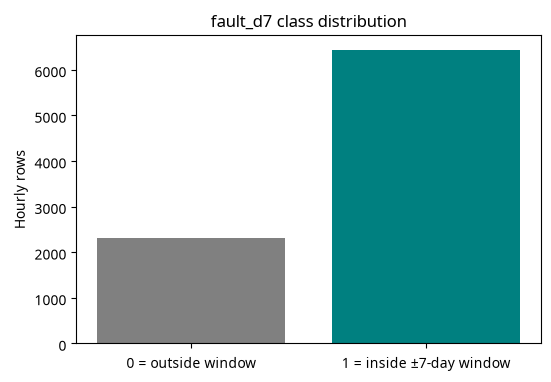

Share of class 1: 73.6 %


In [21]:
class_counts = df[target].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["0 = outside window", "1 = inside ±7-day window"], class_counts.values, color=["gray", "teal"])
plt.title("fault_d7 class distribution")
plt.ylabel("Hourly rows")
plt.savefig("../04_Figures/02_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("Share of class 1:", round(df[target].mean() * 100, 1), "%")

**What we see:** class 1 is the **majority** — about 74% of all hours.
**What it means:** a rule that blindly answers "1" every time is right about 74% of the time. This is the reverse of the usual "rare fault" situation, and it will shape how we judge every model (Sections 11, 14 and 23).

### 4.2 Target over time

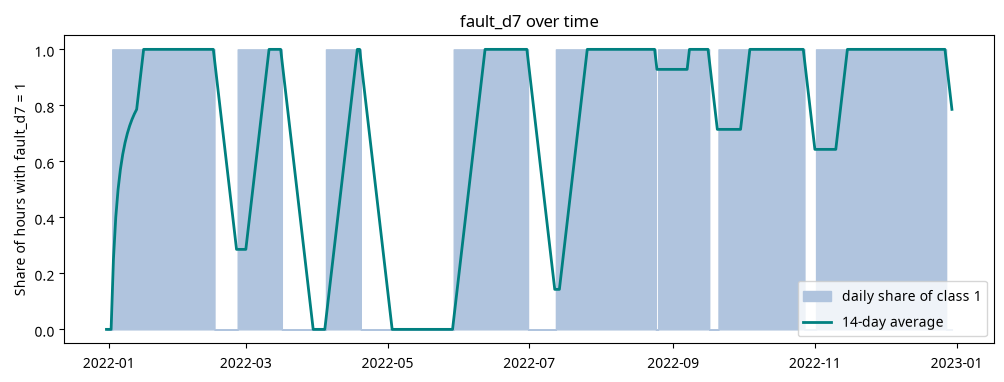

In [22]:
daily_rate = df.set_index("timestamp")[target].resample("D").mean()   # share of positive hours per day

plt.figure(figsize=(12, 4))
plt.fill_between(daily_rate.index, daily_rate.values, step="mid", color="lightsteelblue", label="daily share of class 1")
plt.plot(daily_rate.rolling(14, min_periods=1).mean(), color="teal", linewidth=2, label="14-day average")
plt.title("fault_d7 over time")
plt.ylabel("Share of hours with fault_d7 = 1")
plt.legend(loc="lower right")
plt.savefig("../04_Figures/03_target_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** the label does not flicker randomly. It stays at 1 or 0 for stretches of weeks and then switches. There is a long, almost entirely class-0 stretch in spring (late April to the end of May), and several stretches that are almost entirely class 1.
**What it means:** neighbouring hours share the same label, and the *mix* of classes changes a lot over the year. That is a warning against random splitting (Section 8), and it hints that a model trained on one period may meet a very different situation later.

### 4.3 Monthly pattern

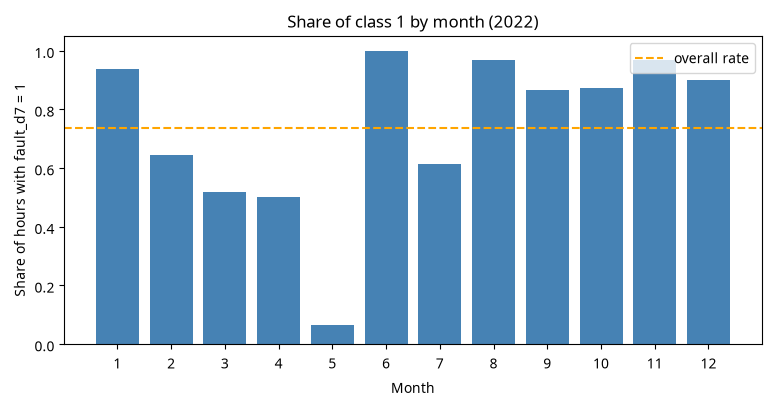

timestamp
1     0.94
2     0.64
3     0.52
4     0.50
5     0.06
6     1.00
7     0.61
8     0.97
9     0.87
10    0.87
11    0.97
12    0.90
Name: fault_d7, dtype: float64

In [23]:
data_2022 = df[df["timestamp"].dt.year == 2022]            # one single hour in 2021 is left out
monthly_rate = data_2022.groupby(data_2022["timestamp"].dt.month)[target].mean()

plt.figure(figsize=(9, 4))
plt.bar(monthly_rate.index, monthly_rate.values, color="steelblue")
plt.axhline(df[target].mean(), color="orange", linestyle="--", label="overall rate")
plt.title("Share of class 1 by month (2022)")
plt.xlabel("Month")
plt.ylabel("Share of hours with fault_d7 = 1")
plt.xticks(range(1, 13))
plt.legend()
plt.savefig("../04_Figures/04_monthly_pattern.png", dpi=120, bbox_inches="tight")
plt.show()

monthly_rate.round(2)

**What we see:** class 1 makes up 94% of hours in January, 50–64% in February–April, only **6% in May**, 100% in June, 61% in July and 87–97% from August to December.
**What it means:** the class balance swings strongly during the year. May is almost entirely class 0, June entirely class 1.

### 4.4 Hour-of-day and day-of-week pattern

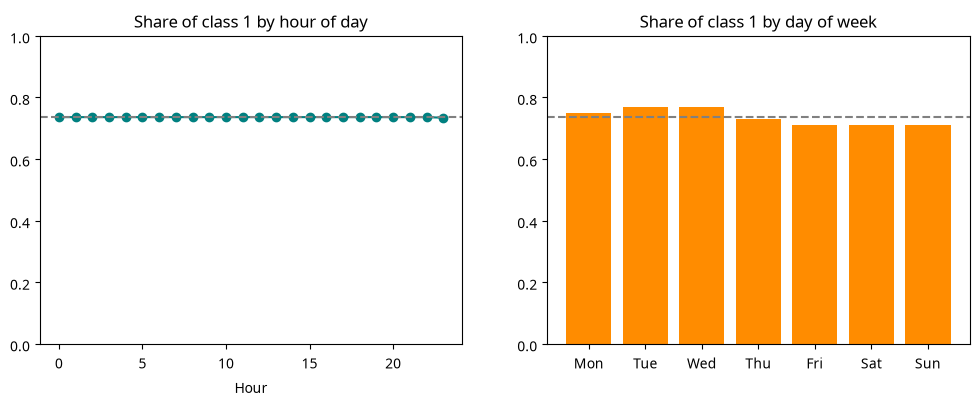

In [24]:
hourly_rate = df.groupby(df["timestamp"].dt.hour)[target].mean()
weekday_rate = df.groupby(df["timestamp"].dt.dayofweek)[target].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hourly_rate.index, hourly_rate.values, marker="o", color="teal")
axes[0].axhline(df[target].mean(), color="gray", linestyle="--")
axes[0].set_ylim(0, 1)
axes[0].set_title("Share of class 1 by hour of day")
axes[0].set_xlabel("Hour")

axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], weekday_rate.values, color="darkorange")
axes[1].axhline(df[target].mean(), color="gray", linestyle="--")
axes[1].set_ylim(0, 1)
axes[1].set_title("Share of class 1 by day of week")

plt.savefig("../04_Figures/05_hour_and_weekday_pattern.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** the hour-of-day line is flat — the share of class 1 is 73.4–73.6% in every hour. Day of week varies a little (71% on Fridays, Saturdays and Sundays up to 77% on Tuesdays and Wednesdays).
**What it means:** the hourly line is flat *by construction*: the label never changes inside a calendar day (Section 5), so every hour of the day gets the same share. Hour of day therefore cannot tell us anything about the label. The day-of-week differences are small and just describe this one year, not a real weekly rule.

### 4.5 Important feature distributions

In [25]:
# Which anomaly scores are most related to the target? (simple correlation with 0/1)
correlation_with_target = df[score_columns].corrwith(df[target])
top_features = correlation_with_target.abs().sort_values(ascending=False).head(6).index.tolist()

correlation_with_target[top_features].round(3)

gw_lvl_site2_anomaly_score      0.322
gw_temp_site2_anomaly_score     0.254
temp_site1_anomaly_score        0.151
sfc_temp_site1_anomaly_score    0.126
326416_ws_vigor                 0.084
279805_ws_vigor                 0.079
dtype: float64

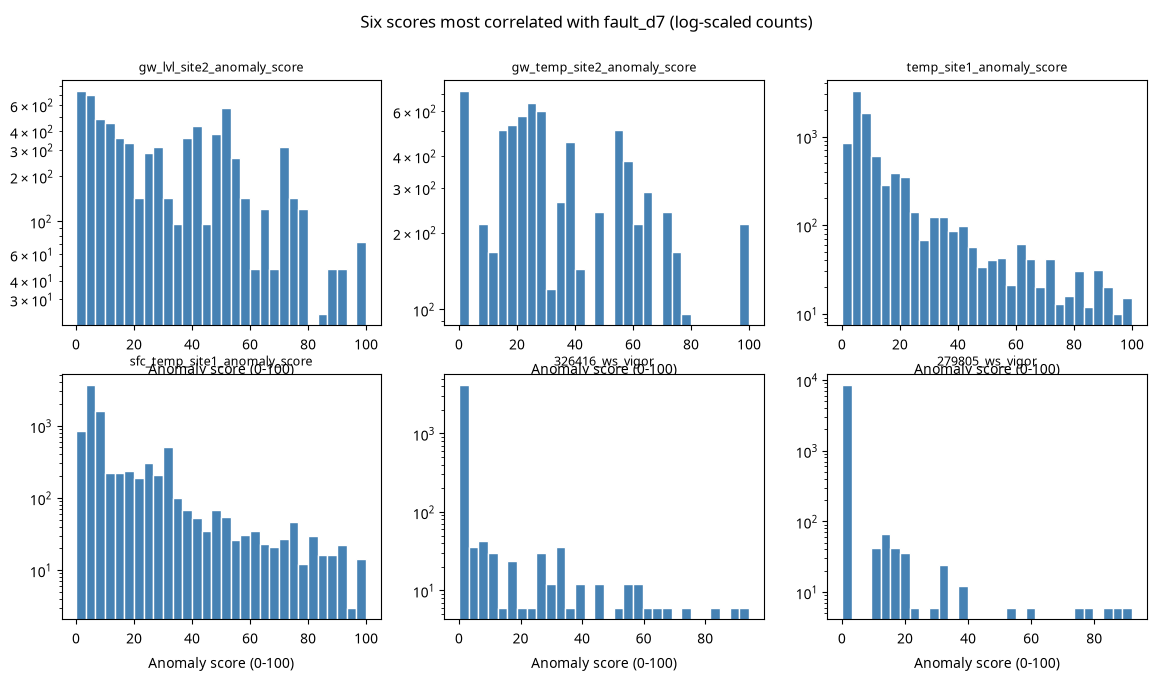

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, column in zip(axes.flat, top_features):
    ax.hist(df[column].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(column, fontsize=9)
    ax.set_xlabel("Anomaly score (0-100)")

fig.suptitle("Six scores most correlated with fault_d7 (log-scaled counts)")
plt.savefig("../04_Figures/06_feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** most of these scores are zero most of the time with rare spikes (that is why the counts use a log scale; `279805_ws_vigor` is exactly 0 in 96% of hours). The groundwater and temperature scores are spread over the whole 0–100 range. Even the *best* single scores correlate only weakly with the target: 0.32 (`gw_lvl_site2`), 0.25 (`gw_temp_site2`), 0.15, 0.13, and under 0.10 for the rest.

**What it means:** no single score separates the classes. Any model must combine many weak signals, so we should expect **modest** performance. (This EDA uses all rows to *understand* the data; no modelling decision depends on it. Section 22 will show that even the strongest of these correlations does not hold over time.)

### 4.6 Correlation

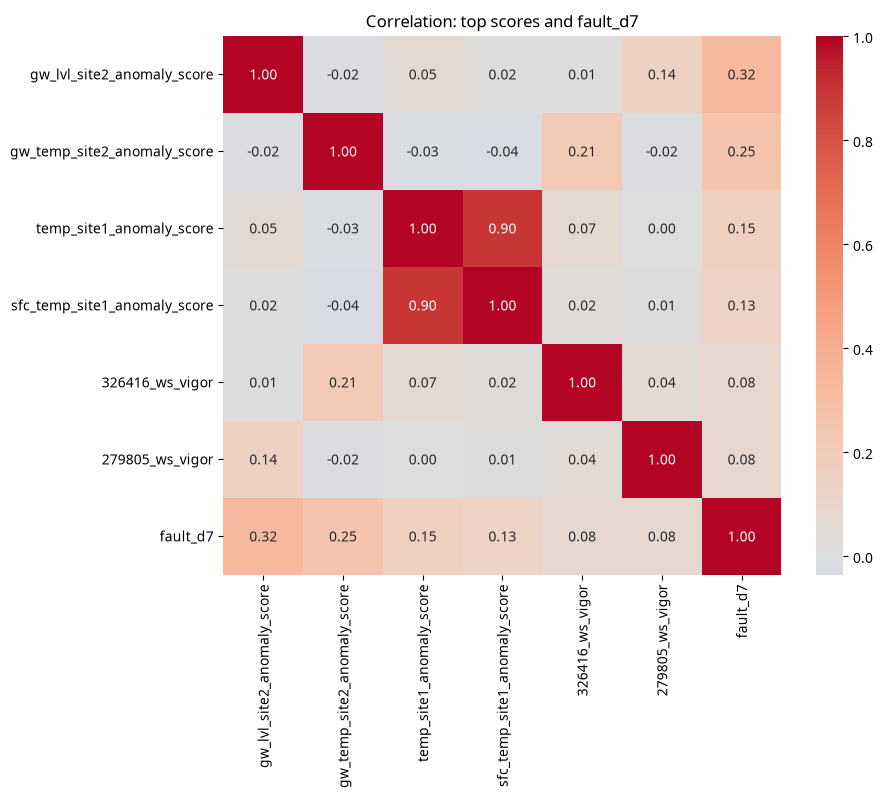

In [27]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[top_features + [target]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: top scores and fault_d7")
plt.savefig("../04_Figures/07_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** the scores are mostly uncorrelated with each other, with one clear exception: `temp_site1` and `sfc_temp_site1` have a correlation of 0.90. Correlation with the target never exceeds 0.32.
**What it means:** the two temperature scores carry almost the same information, so they will share importance. Correlations this low confirm that classification will be hard.

---
# Section 5 — Understand the Target

**What we learn here:** exactly what we are predicting, and what the two classes mean.

### Binary classification in this project
The model looks at one hourly row and chooses one of two classes:

| Class | Meaning in this dataset |
|---|---|
| **0** — normal / non-fault observation | No recorded leak event within ±7 days of this hour |
| **1** — `fault_d7` observation | This hour is within ±7 days (before **or** after) of a recorded leak event |

**Class 1 is called the "positive" class.** "Positive" does *not* mean "good" — it just means "the class we are looking for".

Two accurate statements that prevent common mistakes:
- Class **1** is **not** "a leak is happening now". The window is wide and includes the days *after* an event.
- Class **0** is **not** proof that there is no leak — only that none was *recorded* nearby.

So this is a **leak-proximity / fault classification** problem.

In [28]:
# Every time the label changes, a new "block" starts
block_id = df[target].ne(df[target].shift()).cumsum()

blocks = df.groupby(block_id).agg(label=(target, "first"), hours=(target, "size"))
blocks["days"] = blocks["hours"] / 24

print("Number of blocks:", len(blocks), "| label changes:", len(blocks) - 1)
blocks.groupby("label")["days"].describe().round(1)

Number of blocks: 17 | label changes: 16


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,9.0,10.7,12.4,1.0,3.0,5.0,12.0,40.0
1,8.0,33.5,14.2,15.0,21.2,34.5,43.2,56.0


In [29]:
# Does the label ever change inside one calendar day?
labels_per_day = df.groupby(df["timestamp"].dt.date)[target].nunique()
print("Most different labels seen in a single day:", labels_per_day.max())

Most different labels seen in a single day: 1


**What we see:**
- The label never changes inside a calendar day.
- The 8,737 hours form only **17 blocks** (16 label changes): **8 blocks of class 1** and **9 of class 0**.
- Class-1 blocks last between **15 and 56 days** (average 33.5, median 34.5). Class-0 blocks last between 1 and 40 days (average 10.7, median 5).

**What it means:**
1. The shortest class-1 block is exactly **15 days = 7 days before + the event day + 7 days after**. That matches the documented ±7-day window perfectly. The longer blocks probably come from the windows of nearby events overlapping (the file has no event identifiers, so we cannot check this).
2. The hours are **not independent examples**. There are only about **8 "leak periods"** in the whole year, not 8,737 separate cases. Row-level scores will look more convincing than they deserve.
3. Class 0 means "no recorded event within the window", and these stretches range from one day to almost six weeks.

---
# Section 6 — Date and Time Understanding

**What we learn here:** how time shows up in this dataset.  **Why:** this is time-ordered data, so time affects how we split and evaluate — and some date columns can fool a model.

We create simple calendar columns from `timestamp`: year, month, day, day of week and hour.

In [30]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day                 # day of the month (1-31)
df["day_of_week"] = df["timestamp"].dt.dayofweek   # Monday = 0 ... Sunday = 6
df["hour"] = df["timestamp"].dt.hour               # 0-23

df[["timestamp", "year", "month", "day", "day_of_week", "hour"]].head()

,timestamp,year,month,day,day_of_week,hour
0,2021-12-31 23:00:00,2021,12,31,4,23
1,2022-01-01 00:00:00,2022,1,1,5,0
2,2022-01-01 01:00:00,2022,1,1,5,1
3,2022-01-01 02:00:00,2022,1,1,5,2
4,2022-01-01 03:00:00,2022,1,1,5,3


In [31]:
print(df["year"].value_counts())
print()
print("Months in the data:", sorted(df["month"].unique().tolist()))

year
2022    8736
2021       1
Name: count, dtype: int64

Months in the data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


**What we see:** 8,736 of the 8,737 rows are from 2022 (one hour is from 31 Dec 2021), and each month appears exactly once.

**What it means — which time columns we use:**
- **`year`:** practically constant, so it carries no information. **Not used.**
- **`month` and `day`:** with only one year of data, each month occurs exactly once, so these columns act like a date stamp for a *period*. With a chronological split the model would never have seen the test months in training and could not know what they mean. **Not used.**
- **`hour` and `day_of_week`:** repeating cycles that could in principle matter. EDA shows the hourly pattern is flat and the weekday pattern is weak, so they probably help little. We keep them as simple calendar features and **check in Section 22 whether they actually help**.

---
# Section 7 — Feature Preparation

**What we learn here:** which columns the model gets to see.  **Why:** choosing inputs carefully is part of preventing leakage and over-fitting.

| Role | Columns |
|---|---|
| **Target** (what we predict) | `fault_d7` |
| **Numeric features** | the 18 anomaly scores + `hour` + `day_of_week` (20 features) |
| **Categorical features** | none (everything is already a number) |
| **Not used** | `timestamp` (a raw date cannot be learned from), `year`, `month`, `day` (see Section 6) |

**Why preprocessing is needed:** 5,707 rows have missing values, and some models need inputs on a similar scale. That is handled in Section 10.

In [32]:
feature_columns = score_columns + ["hour", "day_of_week"]

X = df[feature_columns]
y = df[target]

print("Number of features:", len(feature_columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Number of features: 20
X shape: (8737, 20) | y shape: (8737,)


**A note on `hour` and `day_of_week`:** they are plain numbers here (a tree model can still split them sensibly). We include them as simple calendar features, but Section 6 already suggests they carry little information, and Section 22 checks whether they really help.

**What it means:** the model will see one row of 20 numbers and must name the class (0 or 1). Every feature belongs to the **current hour only** — we do not use any neighbouring hours, so no feature is built from the future.

---
# Section 8 — Data Leakage

**What we learn here:** the most common way time-series projects fool themselves.

### What is data leakage?
**Data leakage** is when the model gets information during training or testing that it would **not have in real life** at prediction time. The model then looks great on paper and fails in reality.

### Why random splitting is dangerous for this dataset
In this data, neighbouring hours are almost identical copies of each other — they share the same label (the label never changes inside a day) and very similar sensor conditions. A random split puts hour 10:00 in the training set and hour 11:00 in the test set. The model "recognises" the neighbour and looks brilliant.

**A demonstration** *(demo only — thrown away afterwards).* To keep the final test period untouched, even this demo uses only the first 80% of the rows (Section 9 explains the split). We use `HistGradientBoostingClassifier`, which can handle missing values by itself.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

demo_rows = int(len(df) * 0.80)
X_demo = X.iloc[:demo_rows]
y_demo = y.iloc[:demo_rows]

# WRONG way: shuffle the hours randomly, then split
X_a, X_b, y_a, y_b = train_test_split(X_demo, y_demo, test_size=0.25, random_state=42)
random_model = HistGradientBoostingClassifier(random_state=42).fit(X_a, y_a)
random_proba = random_model.predict_proba(X_b)[:, 1]

# RIGHT way: train on the earlier 75%, test on the later 25%
cut = int(len(X_demo) * 0.75)
time_model = HistGradientBoostingClassifier(random_state=42).fit(X_demo.iloc[:cut], y_demo.iloc[:cut])
time_proba = time_model.predict_proba(X_demo.iloc[cut:])[:, 1]

print("Random split        -> ROC-AUC:", round(roc_auc_score(y_b, random_proba), 4))
print("Chronological split -> ROC-AUC:", round(roc_auc_score(y_demo.iloc[cut:], time_proba), 4))

Random split        -> ROC-AUC: 1.0
Chronological split -> ROC-AUC: 0.5935


**What we see:** the *same model on the same data* scores a ROC-AUC of about **1.0** (essentially perfect) with the random split, but only **0.61** when it must predict a later period.
**What it means:** the near-perfect score is fake. With random shuffling, almost every test hour has a near-identical neighbour hour (same label, similar readings) in the training set, so the model simply recognises neighbours. The chronological score is the honest one, because real use means predicting hours the model has never seen from a period it has never seen.

### Other ways leakage can happen — and how we avoid them

| Leak | How we avoid it |
|---|---|
| Random split mixes future hours into training | Chronological split (Section 9) |
| Scaling / filling missing values using statistics from **all** data | Learn them from **training data only** (Section 10) |
| Features built from future rows (e.g. a "next-hour" average) | We use only the **current row** — no lags or rolling windows |
| Random cross-validation folds | `TimeSeriesSplit` with a gap (Section 15) |
| Choosing a model by peeking at the test set | Test set used **once**, at the end (Section 18) |

### Leakage check on our features

In [34]:
print("Target used as a feature?   ", target in feature_columns)
print("Raw timestamp used as a feature?", "timestamp" in feature_columns)
print("Features:", feature_columns)

Target used as a feature?    False
Raw timestamp used as a feature? False
Features: ['4700008966_kW', '4700008966_power_hour', '4408411600_kW', '4408411600_power_hour', '4608927500_kvar_hour', '238045_ws_temp', '279805_ws_vigor', '279804_ws_level', '279625_ws_temp', '279623_ws_vigor', '319235_ws_temp', '279831_ws_temp', '326417_ws_temp', '326416_ws_vigor', 'temp_site1_anomaly_score', 'sfc_temp_site1_anomaly_score', 'gw_lvl_site2_anomaly_score', 'gw_temp_site2_anomaly_score', 'hour', 'day_of_week']


### Leakage we cannot remove (dataset level)
Two things are built into the dataset and cannot be fixed in this notebook:
1. The label `fault_d7` is defined using days on **both sides** of a leak event, so the label itself uses "future" information about events. This is why the project is *proximity* classification, not forecasting.
2. The anomaly scores were produced by the dataset authors, and we cannot check from this file alone whether each score used only past data.

---
# Section 9 — Chronological Train / Validation / Test Split

**What we learn here:** how to split time-ordered data.  **Why:** to test the model on hours *later* than anything it learned from.

**Training** (learn) → **Validation** (compare models) → **Final Test** (judge the one chosen model, once)

- **Training:** first 60% of the timeline
- **Validation:** next 20%
- **Final test:** last 20% — **kept untouched until Section 18**

**Why must the final test stay untouched?** Every time we look at test results and change something, we *tune the model to the test set*, and the test score stops being an honest estimate of future performance.

(We do **not** use `train_test_split` here. The rows are already sorted by time, so we cut by position.)

In [35]:
n_rows = len(df)
train_end = int(n_rows * 0.60)
dev_end = int(n_rows * 0.80)         # development = training + validation

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:dev_end], y.iloc[train_end:dev_end]
X_test, y_test = X.iloc[dev_end:], y.iloc[dev_end:]

X_dev, y_dev = X.iloc[:dev_end], y.iloc[:dev_end]    # used later for cross-validation

In [36]:
train_dates = df["timestamp"].iloc[:train_end]
val_dates = df["timestamp"].iloc[train_end:dev_end]
test_dates = df["timestamp"].iloc[dev_end:]

split_table = pd.DataFrame({
    "First hour": [train_dates.min(), val_dates.min(), test_dates.min()],
    "Last hour": [train_dates.max(), val_dates.max(), test_dates.max()],
    "Rows": [len(y_train), len(y_val), len(y_test)],
    "Share of class 1": [y_train.mean(), y_val.mean(), y_test.mean()],
    "Class-0 hours": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    "Missing cells": [X_train.isnull().mean().mean(), X_val.isnull().mean().mean(), X_test.isnull().mean().mean()],
}, index=["Training", "Validation", "Final test"])

split_table["Share of class 1"] = split_table["Share of class 1"].round(3)
split_table["Missing cells"] = (split_table["Missing cells"] * 100).round(1).astype(str) + " %"
split_table

,First hour,Last hour,Rows,Share of class 1,Class-0 hours,Missing cells
Training,2021-12-31 23:00:00,2022-08-07 08:00:00,5242,0.620,1993,13.3 %
Validation,2022-08-07 09:00:00,2022-10-19 03:00:00,1747,0.931,120,0.0 %
Final test,2022-10-19 04:00:00,2022-12-30 23:00:00,1748,0.890,192,8.2 %


In [37]:
print("Training ends before validation starts?  ", train_dates.max() < val_dates.min())
print("Validation ends before test starts?      ", val_dates.max() < test_dates.min())

Training ends before validation starts?   True
Validation ends before test starts?       True


Missing sensor data is not spread evenly over the three periods either. Share of missing values (%) for the columns that have any:

In [38]:
missing_by_period = pd.DataFrame({
    "Training": X_train.isnull().mean() * 100,
    "Validation": X_val.isnull().mean() * 100,
    "Final test": X_test.isnull().mean() * 100,
})
missing_by_period = missing_by_period[missing_by_period.sum(axis=1) > 0]
missing_by_period.sort_values("Final test", ascending=False).round(2)

,Training,Validation,Final test
gw_temp_site2_anomaly_score,0.02,0.0,82.38
gw_lvl_site2_anomaly_score,0.02,0.0,82.38
279805_ws_vigor,0.25,0.0,0.00
279804_ws_level,0.25,0.0,0.00
4408411600_kW,41.19,0.0,0.00
4408411600_power_hour,41.19,0.0,0.00
279623_ws_vigor,9.18,0.0,0.00
279625_ws_temp,9.18,0.0,0.00
319235_ws_temp,0.71,0.0,0.00
279831_ws_temp,0.82,0.0,0.00


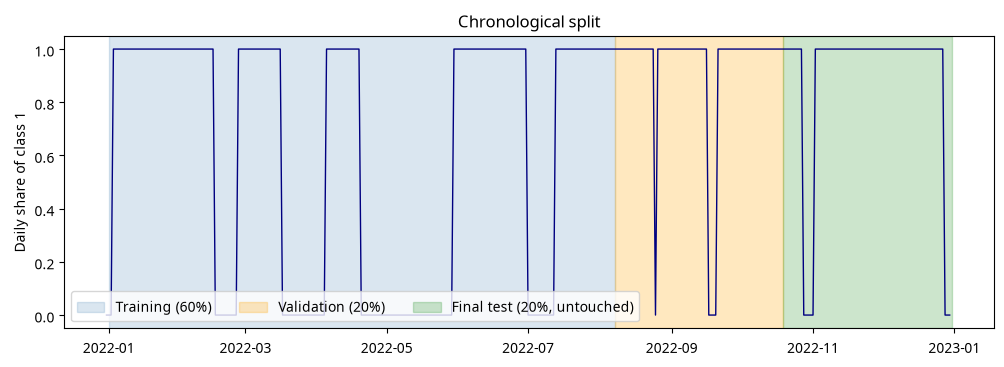

In [39]:
plt.figure(figsize=(12, 3.8))
plt.plot(daily_rate.index, daily_rate.values, color="navy", linewidth=1)
plt.axvspan(train_dates.min(), train_dates.max(), color="steelblue", alpha=0.2, label="Training (60%)")
plt.axvspan(val_dates.min(), val_dates.max(), color="orange", alpha=0.25, label="Validation (20%)")
plt.axvspan(test_dates.min(), test_dates.max(), color="green", alpha=0.2, label="Final test (20%, untouched)")
plt.title("Chronological split")
plt.ylabel("Daily share of class 1")
plt.legend(loc="lower left", ncol=3)
plt.savefig("../04_Figures/08_chronological_split.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:**
- The share of class 1 changes from **62.0% in training** to **93.1% in validation** and **89.0% in the final test**.
- The validation period contains only **120 class-0 hours (5 days)** and the final test only **192 (8 days)**.
- Missing data differs strongly between periods: `326416_ws_vigor` and `326417_ws_temp` are missing in 81% of the training hours but never afterwards; `4408411600_*` is missing in 41% of training hours but never afterwards; and the **groundwater scores are missing in 82% of the final test period** (and in almost no earlier hour).

**What it means:** training, validation and test are three genuinely different situations — a different class mix and, importantly, **different sensors working**. Evaluating "can the model find class 0?" rests on a handful of days, so the results below must be read with that in mind. The test-period baseline "always 1" is already right 89% of the time.

*A small detail:* the split points fall in the middle of a day (for example training ends at 08:00 and validation starts at 09:00 on 7 Aug), and a day shares one label. A few boundary hours therefore share a label across the cut. Cross-validation (Section 15) uses a 14-day gap to avoid this.

---
# Section 10 — Preprocessing

**What we learn here:** getting the numbers ready for the models.

Our features are all numeric, so we need only two steps:

1. **Fill in missing values (imputation).** We replace each missing score with the **median** of that column. We also add a small **"was missing" flag column** for columns that have missing values, because a sensor being down may itself be informative.
2. **Scale the features (standardisation)** — *only for Logistic Regression.* Logistic Regression learns one weight per feature; if features have very different ranges, learning is harder. Standardisation turns each feature into *(value − mean) / standard deviation*. **Random Forest and Gradient Boosting do not need scaling**, because they only ask "is this value above or below a threshold?".

⚠️ **Leakage rule:** the medians, means and standard deviations are learned from the **training data only**, then applied unchanged to validation. (We leave the final test set alone until Section 18.)

In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)
imputer.fit(X_train)                                  # learn the medians from TRAINING data only

column_names = imputer.get_feature_names_out()
X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=column_names, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=column_names, index=X_val.index)

print("Features before:", X_train.shape[1], "| after adding 'was missing' flags:", X_train_imp.shape[1])
print("Missing values in training data before:", X_train.isnull().sum().sum(), "| after:", X_train_imp.isnull().sum().sum())

Features before: 20 | after adding 'was missing' flags: 34
Missing values in training data before: 13924 | after: 0


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_imp)                               # learn mean and std from TRAINING data only

X_train_scaled = scaler.transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)            # same numbers applied to validation

print("Scaled training data -> mean of first 3 columns:", X_train_scaled[:, :3].mean(axis=0).round(2))
print("Scaled training data -> std of first 3 columns: ", X_train_scaled[:, :3].std(axis=0).round(2))

Scaled training data -> mean of first 3 columns: [-0. -0. -0.]
Scaled training data -> std of first 3 columns:  [1. 1. 1.]


**What we see:** the 20 features became 34 columns: 14 "was missing" flags were added, and no missing values remain. After scaling, each training column has mean 0 and standard deviation 1.
**What it means:** all medians, means and standard deviations came from the **training period only**. Validation was transformed with the training numbers, so nothing from the future leaked backwards. The final test set has not been touched.

*(One thing to remember for later: filling a gap with the training median means "pretend this sensor shows a typical value". That is harmless for short gaps, but not for a sensor that is down for two months.)*

---
# Section 11 — Classification Baseline

**What we learn here:** how good is a *very simple* prediction?  **Why:** a machine-learning model is only worth it if it beats something simple.

**Before using ML, what happens if we make a simple prediction?** Our baseline ignores all sensor data and **always predicts the most common class in the training data**. Here that class is 1, so the baseline says "inside a leak-proximity window" for every hour.

We show three metrics for now (all are explained in Section 13): **Accuracy** (share of correct answers), **F1** (balance of precision and recall) and **ROC-AUC** (how well scores rank class 1 above class 0; 0.5 = no better than chance).

In [42]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_imp, y_train)

pred_baseline = baseline.predict(X_val_imp)
proba_baseline = baseline.predict_proba(X_val_imp)[:, 1]

print("Baseline predicts class:", pred_baseline[0], "for every row")
print("Accuracy:", round(accuracy_score(y_val, pred_baseline), 3))
print("F1:      ", round(f1_score(y_val, pred_baseline), 3))
print("ROC-AUC: ", round(roc_auc_score(y_val, proba_baseline), 3))

Baseline predicts class: 1 for every row
Accuracy: 0.931
F1:       0.964
ROC-AUC:  0.5


**What we see:** the baseline predicts class 1 for every row. It still scores accuracy **0.931** (exactly the share of class 1 in validation) and F1 **0.964**. Its ROC-AUC is exactly **0.5**.
**What it means:** in the validation period 93% of hours are class 1, so the "do nothing smart" rule is already extremely hard to beat on accuracy and F1. Every model must be compared with this row. The ROC-AUC of 0.5 shows that the baseline has *no* ability to tell the classes apart.

---
# Section 12 — Classification Models

We train three sensible models. For each one: **Explain → Train → Predict → Evaluate** on the validation set.

Every model gives two kinds of output: a **class** (`predict`: 0 or 1) and a **probability** of class 1 (`predict_proba`). The class uses a cut-off of **0.50** (probability ≥ 0.5 → class 1). We never change this cut-off using the test set.

### 12.1 Logistic Regression
**Explain:** despite its name, it is a classifier. It gives each feature a weight, adds them up, and turns the total into a probability between 0 and 1. Simple, fast, and the weights can be inspected. It can only draw a straight-line boundary. It uses the **scaled** data.

In [43]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)                          # Train

pred_lr = lr_model.predict(X_val_scaled)                       # Predict
proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

print("Logistic Regression -> Accuracy:", round(accuracy_score(y_val, pred_lr), 3),      # Evaluate
      "| F1:", round(f1_score(y_val, pred_lr), 3),
      "| ROC-AUC:", round(roc_auc_score(y_val, proba_lr), 3))

Logistic Regression -> Accuracy: 0.916 | F1: 0.956 | ROC-AUC: 0.361


### 12.2 Random Forest
**Explain:** builds many decision trees (each asks a series of yes/no questions such as *"is the groundwater-level score above 12?"*) on random parts of the data and lets them **vote**. Handles curved and "if-then" patterns, and is hard to over-fit badly. It uses the imputed, **unscaled** data.

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_imp, y_train)                             # Train

pred_rf = rf_model.predict(X_val_imp)                          # Predict
proba_rf = rf_model.predict_proba(X_val_imp)[:, 1]

print("Random Forest -> Accuracy:", round(accuracy_score(y_val, pred_rf), 3),            # Evaluate
      "| F1:", round(f1_score(y_val, pred_rf), 3),
      "| ROC-AUC:", round(roc_auc_score(y_val, proba_rf), 3))

Random Forest -> Accuracy: 0.931 | F1: 0.964 | ROC-AUC: 0.344


### 12.3 HistGradientBoosting
**Explain:** also uses decision trees, but builds them **one after another**, each new tree trying to fix the mistakes of the previous ones. Often very strong on tables of numbers, and fast. It also uses the imputed, unscaled data.

In [45]:
hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train_imp, y_train)                            # Train

pred_hgb = hgb_model.predict(X_val_imp)                        # Predict
proba_hgb = hgb_model.predict_proba(X_val_imp)[:, 1]

print("HistGradientBoosting -> Accuracy:", round(accuracy_score(y_val, pred_hgb), 3),    # Evaluate
      "| F1:", round(f1_score(y_val, pred_hgb), 3),
      "| ROC-AUC:", round(roc_auc_score(y_val, proba_hgb), 3))

HistGradientBoosting -> Accuracy: 0.849 | F1: 0.918 | ROC-AUC: 0.61


**What we see (validation):**

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Baseline | 0.931 | 0.964 | 0.500 |
| Logistic Regression | 0.916 | 0.956 | 0.361 |
| Random Forest | 0.931 | 0.964 | 0.344 |
| HistGradientBoosting | 0.849 | 0.918 | 0.637 |

**What it means:** no model beats the baseline on accuracy or F1. Random Forest only *ties* it (it ended up predicting class 1 for every row too), while Logistic Regression and HistGradientBoosting are worse. For Logistic Regression and Random Forest the ROC-AUC is **below 0.5**: they rank the class-0 hours as *more* likely to be class 1 than the real class-1 hours — worse than a coin flip. Only HistGradientBoosting is above 0.5. The validation period contains just five class-0 days, so this is one very small window; Section 15 gives a broader comparison.

---
# Section 13 — Classification Metrics

**What we learn here:** how to measure a classifier — and why one number is never enough.

### The four possible outcomes (class 1 = "inside a leak-proximity window" is the positive class)

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | **True Negative (TN)** — correctly said "outside" | **False Positive (FP)** — said "inside", but actually outside (a *false alarm*) |
| **Actual 1** | **False Negative (FN)** — said "outside", but actually inside (a *miss*) | **True Positive (TP)** — correctly said "inside" |

This table of counts is the **confusion matrix**.

### The metrics

| Metric | Formula / idea | In simple words |
|---|---|---|
| **Accuracy** | (TP + TN) / all | Share of all answers that were right |
| **Precision** | TP / (TP + FP) | Of the hours we flagged as class 1, how many really were? |
| **Recall** | TP / (TP + FN) | Of the real class-1 hours, how many did we find? |
| **F1-score** | 2 × (precision × recall) / (precision + recall) | One number balancing precision and recall |
| **ROC-AUC** | uses probabilities | Chance that a random class-1 hour gets a higher probability than a random class-0 hour. **0.5 = coin flip, 1.0 = perfect** |
| **PR-AUC** | uses probabilities | Area under the precision-recall curve (we use scikit-learn's *average precision*). **Its "no skill" level equals the share of class 1**, not 0.5 |

### A tiny example
Ten hours: 8 are really class 1, 2 are class 0.

In [46]:
from sklearn.metrics import precision_score, recall_score, average_precision_score, confusion_matrix

actual    = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0])
predicted = np.array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0])
probability = np.array([0.9, 0.8, 0.8, 0.7, 0.7, 0.6, 0.6, 0.4, 0.55, 0.2])

tn, fp, fn, tp = confusion_matrix(actual, predicted).ravel()
print("TN =", tn, "| FP =", fp, "| FN =", fn, "| TP =", tp)
print()
print("Accuracy  =", (tp + tn) / 10)
print("Precision =", round(precision_score(actual, predicted), 3), "  (7 / (7 + 1))")
print("Recall    =", round(recall_score(actual, predicted), 3), "  (7 / (7 + 1))")
print("F1        =", round(f1_score(actual, predicted), 3))
print("ROC-AUC   =", round(roc_auc_score(actual, probability), 3))
print("PR-AUC    =", round(average_precision_score(actual, probability), 3))

TN = 1 | FP = 1 | FN = 1 | TP = 7

Accuracy  = 0.8
Precision = 0.875   (7 / (7 + 1))
Recall    = 0.875   (7 / (7 + 1))
F1        = 0.875
ROC-AUC   = 0.938
PR-AUC    = 0.986


Now we calculate all six metrics, plus the confusion-matrix counts, for the baseline and the three models on the **validation** set.

In [47]:
val_pred = {"Baseline (most frequent)": pred_baseline, "Logistic Regression": pred_lr,
            "Random Forest": pred_rf, "HistGradientBoosting": pred_hgb}
val_proba = {"Baseline (most frequent)": proba_baseline, "Logistic Regression": proba_lr,
             "Random Forest": proba_rf, "HistGradientBoosting": proba_hgb}

val_metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"])
val_counts = pd.DataFrame(columns=["TN", "FP", "FN", "TP"])

for name in val_pred:
    pred = val_pred[name]
    proba = val_proba[name]
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    val_metrics.loc[name] = [accuracy_score(y_val, pred), precision_score(y_val, pred, zero_division=0),
                             recall_score(y_val, pred, zero_division=0), f1_score(y_val, pred),
                             roc_auc_score(y_val, proba), average_precision_score(y_val, proba)]
    val_counts.loc[name] = [tn, fp, fn, tp]

val_metrics.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (most frequent),0.931,0.931,1.000,0.964,0.500,0.931
Logistic Regression,0.916,0.930,0.983,0.956,0.361,0.925
Random Forest,0.931,0.931,1.000,0.964,0.344,0.908
HistGradientBoosting,0.849,0.925,0.911,0.918,0.610,0.964


In [48]:
val_counts

,TN,FP,FN,TP
Baseline (most frequent),0,120,0,1627
Logistic Regression,0,120,27,1600
Random Forest,0,120,0,1627
HistGradientBoosting,0,120,144,1483


**What we see (validation):**
- **True negatives are 0 for every model:** none of them correctly identifies any of the 120 class-0 hours.
- Random Forest gives exactly the same answers as the baseline (120 false positives, 0 false negatives). Logistic Regression additionally misses 27 class-1 hours, and HistGradientBoosting misses 144.
- **PR-AUC:** the "no skill" level is 0.931. Logistic Regression (0.925) and Random Forest (0.908) are *below* it; HistGradientBoosting (0.964) is slightly above it.

**What it means:** on this validation window the models either copy the baseline or do worse. The only metric that favours any model is HistGradientBoosting's ROC-AUC/PR-AUC, and that rests on five class-0 days.

---
# Section 14 — Why Accuracy Can Be Misleading

**What we learn here:** why a high score can hide a useless model.

### Class imbalance — in this dataset the *positive* class is the majority
We usually hear about imbalance when the class of interest is **rare** (for example 1% faults) — then "always predict normal" has 99% accuracy but finds nothing. Here it is **reversed**: class 1 is the **majority**.

In [49]:
print("Share of class 1 -> training:", round(y_train.mean(), 3),
      "| validation:", round(y_val.mean(), 3),
      "| final test:", round(y_test.mean(), 3))

Share of class 1 -> training: 0.62 | validation: 0.931 | final test: 0.89


Let us see what two "lazy" predictors score on the validation set — one that always says 1, one that always says 0:

In [50]:
always_one = np.ones(len(y_val), dtype=int)
always_zero = np.zeros(len(y_val), dtype=int)

lazy = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
for name, pred in {"Always predict 1": always_one, "Always predict 0": always_zero}.items():
    lazy.loc[name] = [accuracy_score(y_val, pred), precision_score(y_val, pred, zero_division=0),
                      recall_score(y_val, pred, zero_division=0), f1_score(y_val, pred, zero_division=0),
                      roc_auc_score(y_val, pred)]
lazy.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Always predict 1,0.931,0.931,1.0,0.964,0.5
Always predict 0,0.069,0.000,0.0,0.000,0.5


**What we see:** "always predict 1" scores accuracy **0.931**, recall **1.0**, precision 0.931 and F1 **0.964** — without looking at a single sensor — and a ROC-AUC of exactly 0.5. "Always predict 0" gets accuracy 0.069 and recall 0.

**What it means — why accuracy alone misleads:**
- **Accuracy** rewards guessing the majority class. A model can score 93% while understanding nothing.
- In a *rare-fault* problem (faults are 1% of data) we use **Precision, Recall, F1 and PR-AUC** because accuracy hides that the faults are missed. Those are the right tools there.
- In **this** dataset the positive class is the majority, so even those metrics are **flattered**: recall of 1.0 and F1 of 0.96 are trivially achievable. They are only meaningful when compared with the "always 1" row.

**Practical rules we follow from now on:**
1. Always show the baseline row next to the model.
2. Compare PR-AUC with its "no skill" level (= share of class 1), not with 0.5.
3. Use ROC-AUC (chance level always 0.5) as the main selection metric.
4. Look at **both classes**: confusion-matrix counts, specificity and balanced accuracy (Section 23).

---
# Section 15 — Time-Series Cross-Validation

**What we learn here:** a more reliable way to compare models.  **Why:** one validation period can be lucky or unlucky.

### Why not ordinary (random) cross-validation?
Ordinary K-fold cross-validation shuffles rows into folds, so hour 10:00 may be in training and hour 11:00 in validation — the leakage we saw in Section 8. Some folds would even train on the future and test on the past.

### `TimeSeriesSplit`
It makes several splits where **training always comes before validation** and the training part grows each time. We use only the **development period** (training + validation); the final test is not involved.

**What is `gap=336`?** The label covers ±7 days around an event. A window could straddle the boundary between training and validation. We leave a gap of 336 hours (14 days) between them so the two parts do not share the same event window.

In [51]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, gap=336)
dev_dates = df["timestamp"].iloc[:dev_end]

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    print("Fold", fold,
          "| train:", dev_dates.iloc[train_idx[0]].date(), "to", dev_dates.iloc[train_idx[-1]].date(),
          "| validate:", dev_dates.iloc[val_idx[0]].date(), "to", dev_dates.iloc[val_idx[-1]].date(),
          "| share of class 1 in validation fold:", round(y_dev.iloc[val_idx].mean(), 2))

Fold 1 | train: 2021-12-31 to 2022-02-04 | validate: 2022-02-18 to 2022-04-08 | share of class 1 in validation fold: 0.46
Fold 2 | train: 2021-12-31 to 2022-03-25 | validate: 2022-04-08 to 2022-05-26 | share of class 1 in validation fold: 0.24
Fold 3 | train: 2021-12-31 to 2022-05-12 | validate: 2022-05-26 to 2022-07-14 | share of class 1 in validation fold: 0.68
Fold 4 | train: 2021-12-31 to 2022-06-30 | validate: 2022-07-14 to 2022-08-31 | share of class 1 in validation fold: 0.98
Fold 5 | train: 2021-12-31 to 2022-08-17 | validate: 2022-08-31 to 2022-10-19 | share of class 1 in validation fold: 0.92


**What we see:** the training part grows with each fold, the validation part is always later, and there is a 14-day gap between them. The share of class 1 in the validation folds is very different: 0.46, 0.24, 0.68, 0.98, 0.92.
**What it means:** each fold imitates real life — *learn from the past, predict what comes next* — and no fold trains on the future. Because the class mix changes so much between folds (fold 2 is only 24% class 1, fold 4 is 98%), scores will vary a lot from fold to fold. Fold 1 is trained on only five weeks of data.

### Cross-validating the models
**Why pipelines now?** In cross-validation the imputer (and scaler) must be learned again on the training part of *each fold*, never on the validation part. `make_pipeline` chains *preprocessing → model* and does exactly that automatically. It is the only pipeline in this notebook.

In [52]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

baseline_pipe = make_pipeline(SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True),
                              DummyClassifier(strategy="most_frequent"))
lr_pipe = make_pipeline(SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True), StandardScaler(),
                        LogisticRegression(max_iter=2000, random_state=42))
rf_pipe = make_pipeline(SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True),
                        RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1))
hgb_pipe = make_pipeline(SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True),
                         HistGradientBoostingClassifier(random_state=42))

scoring = {"Accuracy": "accuracy", "Precision": "precision", "Recall": "recall",
           "F1": "f1", "ROC-AUC": "roc_auc", "PR-AUC": "average_precision"}

In [53]:
cv_models = {"Baseline (most frequent)": baseline_pipe, "Logistic Regression": lr_pipe,
             "Random Forest": rf_pipe, "HistGradientBoosting": hgb_pipe}

cv_table = pd.DataFrame(columns=list(scoring))
cv_roc_by_fold = pd.DataFrame()

for name in cv_models:
    result = cross_validate(cv_models[name], X_dev, y_dev, cv=tscv, scoring=scoring)
    cv_table.loc[name] = [result["test_" + metric].mean() for metric in scoring]
    cv_roc_by_fold[name] = result["test_ROC-AUC"]

print("Mean of the 5 folds:")
cv_table.round(3)

Mean of the 5 folds:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (most frequent),0.656,0.656,1.000,0.756,0.500,0.656
Logistic Regression,0.614,0.652,0.754,0.663,0.385,0.630
Random Forest,0.550,0.474,0.589,0.510,0.279,0.589
HistGradientBoosting,0.494,0.572,0.599,0.555,0.331,0.640


In [54]:
cv_roc_by_fold.index = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]
print("ROC-AUC in each fold:")
cv_roc_by_fold.round(3)

ROC-AUC in each fold:


,Baseline (most frequent),Logistic Regression,Random Forest,HistGradientBoosting
Fold 1,0.5,0.283,0.377,0.426
Fold 2,0.5,0.299,0.070,0.034
Fold 3,0.5,0.612,0.233,0.259
Fold 4,0.5,0.376,0.454,0.413
Fold 5,0.5,0.352,0.260,0.524


**What we see (mean of 5 folds):**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| **Baseline** | **0.656** | **0.656** | **1.000** | **0.756** | **0.500** | **0.656** |
| Logistic Regression | 0.614 | 0.652 | 0.754 | 0.663 | 0.385 | 0.630 |
| Random Forest | 0.550 | 0.474 | 0.589 | 0.510 | 0.279 | 0.589 |
| HistGradientBoosting | 0.475 | 0.567 | 0.587 | 0.545 | 0.309 | 0.628 |

Per fold, only **one** of the 15 ROC-AUC values for the three models is above 0.5 (Logistic Regression in fold 3: 0.612). Random Forest ranges from 0.07 to 0.45 and HistGradientBoosting from 0.03 to 0.43.

**What it means:**
- The do-nothing **baseline is better than every ML model on all six metrics**.
- Every ML model has a mean ROC-AUC **below 0.5**: models trained on the past rank later hours *worse than chance*. The relationships they learn in earlier periods do not hold — in places they reverse (Section 22 shows how).
- ⚠️ A ROC-AUC below 0.5 does **not** mean "just flip the predictions and you get a good model". The direction is not stable (one fold is above 0.5), and we could not know the right direction in advance.

---
# Section 16 — Hyperparameters and GridSearchCV

### What is a hyperparameter?
- A **parameter** is something the model **learns** from data (for example the weights in Logistic Regression).
- A **hyperparameter** is a **setting we choose before training** (for example how deep a tree may grow).

Different settings give different results. **Hyperparameter tuning** = trying a few settings and keeping the best.

### GridSearchCV
`GridSearchCV` tries **every combination** from a small grid, scores each one with cross-validation, and reports the best. We pass it our `TimeSeriesSplit`, so the search respects time order, and we use only the development period.

**Which model do we tune, and what do we score?** We need a rule *before* looking at results. Because the majority class makes accuracy, recall, F1 and PR-AUC look good even for useless predictors (Section 14), our **primary selection metric is ROC-AUC** — its "no skill" level is always 0.5, whatever the class balance. PR-AUC and F1 are supporting evidence. We tune the model that has the best mean cross-validated ROC-AUC in Section 15.

In [55]:
print(cv_table["ROC-AUC"].sort_values(ascending=False).round(3))

Baseline (most frequent)    0.500
Logistic Regression         0.385
HistGradientBoosting        0.331
Random Forest               0.279
Name: ROC-AUC, dtype: float64


**Which model do we tune?** By the rule above (best mean CV ROC-AUC among the machine-learning models), it is **Logistic Regression** (0.385), ahead of HistGradientBoosting (0.309) and Random Forest (0.279). Note that all three are *below* the baseline's 0.500 — we tune Logistic Regression to learn the tool, and to see whether tuning can rescue it.

Two hyperparameters, **8 combinations** in total:
- `C` — the inverse of the *regularisation strength*. A **small** `C` forces the weights to stay small, which gives a simpler, more cautious model. A large `C` lets the weights grow.
- `class_weight` — `None` treats all hours equally; `"balanced"` gives more weight to the rarer class (class 0).

Our starting setting (`C=1`, `class_weight=None`) is inside the grid, so the search can only match or beat it.

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__class_weight": [None, "balanced"],
}

lr_search_pipe = make_pipeline(SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True), StandardScaler(),
                               LogisticRegression(max_iter=2000, random_state=42))

grid = GridSearchCV(lr_search_pipe, param_grid, cv=tscv, scoring="roc_auc")
grid.fit(X_dev, y_dev)

print("Best settings:", grid.best_params_)
print("Best mean CV ROC-AUC:", round(grid.best_score_, 4))

Best settings: {'logisticregression__C': 0.01, 'logisticregression__class_weight': 'balanced'}
Best mean CV ROC-AUC: 0.4059


In [57]:
grid_table = pd.DataFrame({
    "C": grid.cv_results_["param_logisticregression__C"],
    "class_weight": pd.Series(grid.cv_results_["param_logisticregression__class_weight"]).astype(str),
    "CV ROC-AUC": grid.cv_results_["mean_test_score"],
})
grid_table.sort_values("CV ROC-AUC", ascending=False).round(3)

,C,class_weight,CV ROC-AUC
1,0.01,balanced,0.406
0,0.01,NaN,0.402
3,0.10,balanced,0.394
2,0.10,NaN,0.393
7,10.00,balanced,0.387
5,1.00,balanced,0.385
6,10.00,NaN,0.385
4,1.00,NaN,0.385


**What we see:** the best setting is `C=0.01` with `class_weight="balanced"`, giving a CV ROC-AUC of **0.406**. All eight combinations lie between 0.385 and 0.406; stronger regularisation (smaller `C`) helped a little, and the class weight made almost no difference.
**What it means:** tuning moved the score from 0.385 to 0.406 — still well **below 0.5**. Hyperparameter tuning cannot repair a relationship that does not hold over time. (Also note the best score is the maximum of 8 tries, so it is slightly optimistic.)

---
# Section 17 — Model Comparison

**What we learn here:** which model is best, judged with several metrics.

We compare the five candidates with the same **time-aware cross-validation** (mean of 5 folds): baseline, Logistic Regression, Random Forest, HistGradientBoosting and the tuned Random Forest.

In [58]:
tuned_pipe = grid.best_estimator_
tuned_result = cross_validate(tuned_pipe, X_dev, y_dev, cv=tscv, scoring=scoring)
cv_table.loc["Tuned Logistic Regression"] = [tuned_result["test_" + metric].mean() for metric in scoring]

comparison = cv_table.sort_values("ROC-AUC", ascending=False)
comparison.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (most frequent),0.656,0.656,1.000,0.756,0.500,0.656
Tuned Logistic Regression,0.655,0.677,0.695,0.637,0.406,0.640
Logistic Regression,0.614,0.652,0.754,0.663,0.385,0.630
HistGradientBoosting,0.494,0.572,0.599,0.555,0.331,0.640
Random Forest,0.550,0.474,0.589,0.510,0.279,0.589


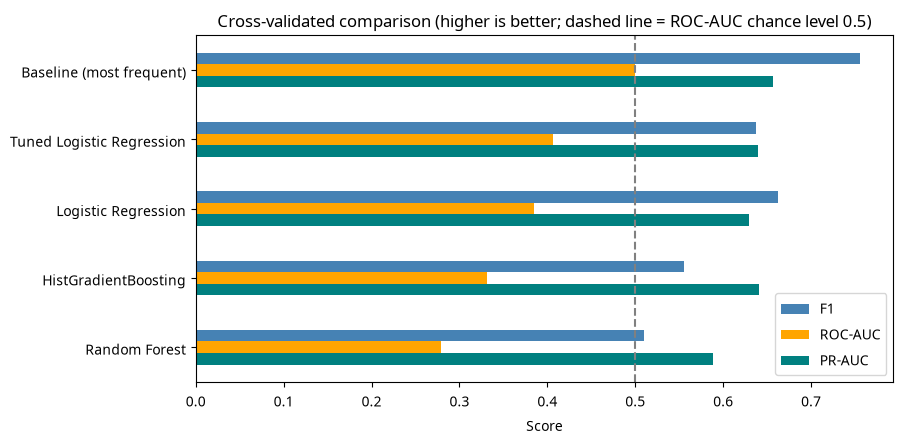

In [59]:
comparison[["F1", "ROC-AUC", "PR-AUC"]].plot(kind="barh", figsize=(9, 4.5), color=["steelblue", "orange", "teal"])
plt.axvline(0.5, color="gray", linestyle="--")
plt.title("Cross-validated comparison (higher is better; dashed line = ROC-AUC chance level 0.5)")
plt.xlabel("Score")
plt.gca().invert_yaxis()
plt.savefig("../04_Figures/09_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:** by cross-validated ROC-AUC the order is **baseline (0.500)** > tuned Logistic Regression (0.406) > Logistic Regression (0.385) > HistGradientBoosting (0.309) > Random Forest (0.279). The tuned Logistic Regression is the best *machine-learning* model, and it roughly ties the baseline on accuracy (0.655 vs 0.656) and has a slightly higher precision (0.677 vs 0.656) — but it is worse on recall, F1, ROC-AUC and PR-AUC.

**What it means:** among the ML models the **tuned Logistic Regression** is best, so that is the model we will test. But **no ML model beats the do-nothing baseline** in cross-validation. The honest development result is that, on this data, machine learning adds nothing over "always predict the most common class". We select using ROC-AUC, **not** accuracy.

---
# Section 18 — Final Model and Untouched Test

**What we learn here:** the honest, final estimate.

**Selection (made from development data only).** Our rule: the best cross-validated ROC-AUC. The result in Section 17: baseline 0.500 > tuned Logistic Regression 0.406 > Logistic Regression 0.385 > HistGradientBoosting 0.309 > Random Forest 0.279. Two consequences:
1. Among the **machine-learning** models, the **tuned Logistic Regression** is best. It is our *final model* (`GridSearchCV` has already re-trained it on the whole development period, training + validation).
2. But **no ML model beats the baseline**, so the development evidence says the do-nothing rule is the better decision rule. We still test the final ML model — to learn *how* it behaves — and we put the baseline next to it.

**The final test set is used only once for the final estimate.** Now, for the first and only time, we predict the last 20% of the timeline.

In [60]:
final_model = grid.best_estimator_                     # tuned Logistic Regression, trained on the development period

final_pred = final_model.predict(X_test)               # first and only look at the test period
final_proba = final_model.predict_proba(X_test)[:, 1]

baseline_pipe.fit(X_dev, y_dev)                        # baseline, for comparison
base_pred = baseline_pipe.predict(X_test)
base_proba = baseline_pipe.predict_proba(X_test)[:, 1]

In [61]:
test_pred = {"Baseline (most frequent)": base_pred, "Tuned Logistic Regression (final)": final_pred}
test_proba = {"Baseline (most frequent)": base_proba, "Tuned Logistic Regression (final)": final_proba}

test_metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"])
for name in test_pred:
    pred = test_pred[name]
    proba = test_proba[name]
    test_metrics.loc[name] = [accuracy_score(y_test, pred), precision_score(y_test, pred, zero_division=0),
                              recall_score(y_test, pred, zero_division=0), f1_score(y_test, pred),
                              roc_auc_score(y_test, proba), average_precision_score(y_test, proba)]

print("Share of class 1 in the test period:", round(y_test.mean(), 4))
test_metrics.round(4)

Share of class 1 in the test period: 0.8902


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (most frequent),0.8902,0.8902,1.0000,0.9419,0.5000,0.8902
Tuned Logistic Regression (final),0.2918,0.8046,0.2699,0.4042,0.3101,0.8228


**What we see (final test, 1,748 hours, 89.0% class 1):**

| | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| **Baseline** | **0.890** | **0.890** | **1.000** | **0.942** | **0.500** | **0.890** |
| Final model (tuned Logistic Regression) | 0.292 | 0.805 | 0.270 | 0.404 | 0.310 | 0.823 |

**What it means:**
- The ML model is **worse than the do-nothing baseline on every metric**. Accuracy collapses from 0.890 to 0.292, and recall from 1.0 to 0.27: it misses almost three quarters of the class-1 hours.
- **ROC-AUC is 0.31** — below the coin-flip level of 0.5. The model ranks the hours in the *wrong direction*. PR-AUC (0.823) is below its no-skill level (0.890).
- The cross-validation had already warned us (tuned ROC-AUC 0.406 < 0.5); the test confirms it.
- The test set is used only this once; we change nothing after seeing these numbers.

---
# Section 19 — Confusion Matrix

**What we learn here:** exactly *what kind* of mistakes the final model makes.

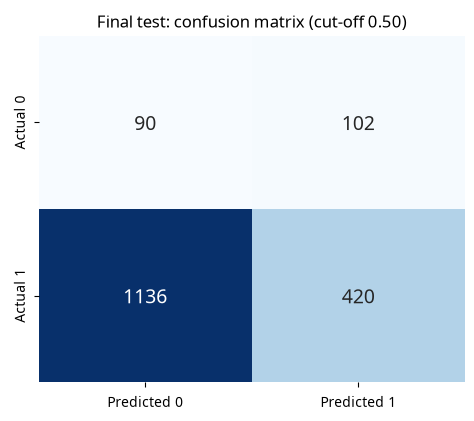

True negatives : 90
False positives: 102
False negatives: 1136
True positives : 420


In [62]:
cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"],
            annot_kws={"fontsize": 14})
plt.title("Final test: confusion matrix (cut-off 0.50)")
plt.savefig("../04_Figures/10_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)

**What the four numbers mean (final test):**
- **True negatives (90):** class-0 hours correctly called class 0.
- **False positives (102):** class-0 hours wrongly called class 1.
- **False negatives (1,136):** class-1 hours the model missed.
- **True positives (420):** class-1 hours correctly found.

Recall = 420 / 1,556 = **27.0%**. Specificity = 90 / 192 = **46.9%**. Precision = 420 / 522 = **80.5%**. The model says "class 1" for only **29.9%** of hours, while the true share is 89.0%.

**What these errors mean for a water network:**
- A **false negative** here means "an hour inside a leak-proximity window was called normal". There are **1,136** of them — the model misses 73% of in-window hours. A monitoring system that missed this much would be useless.
- A **false positive** means "this hour was flagged although no leak event is recorded within 7 days" — a false alarm. There are 102 (96 of them in four consecutive days in October).
- Do not be impressed by the 90 true negatives: Section 21 shows they are mostly a side-effect of the model saying "class 0" for most hours of a sensor outage.

---
# Section 20 — ROC and Precision-Recall Curves

**What we learn here:** how the model behaves across *all* possible cut-offs, not only 0.50.

- **ROC curve:** for every cut-off, plots the share of real class-1 hours found (true-positive rate, *y*) against the share of class-0 hours wrongly flagged (false-positive rate, *x*). A curve hugging the top-left corner is great; the **diagonal is a coin flip** (ROC-AUC 0.5).
- **Precision-recall curve:** for every cut-off, plots precision against recall. The **dashed line is the "no-skill" level = the share of class 1**.

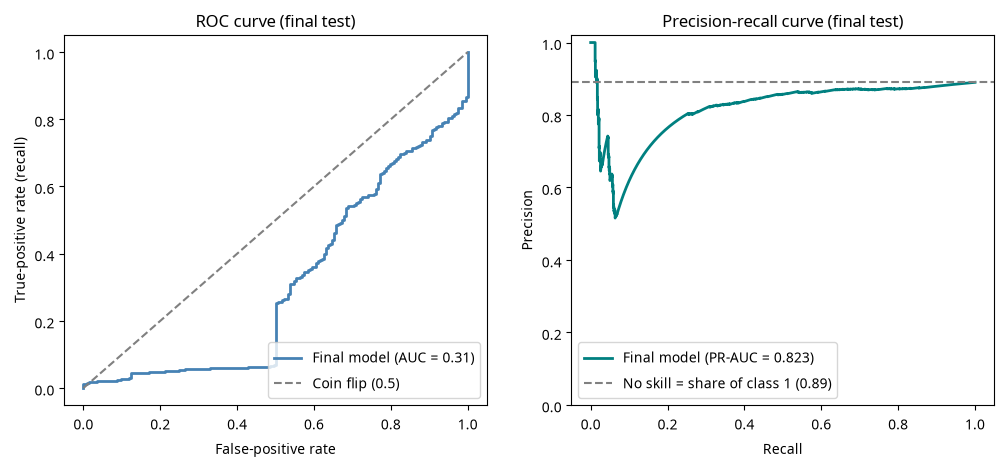

In [63]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, final_proba)
precision_values, recall_values, _ = precision_recall_curve(y_test, final_proba)
test_prevalence = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(fpr, tpr, color="steelblue", linewidth=2, label="Final model (AUC = " + str(round(roc_auc_score(y_test, final_proba), 3)) + ")")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Coin flip (0.5)")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate (recall)")
axes[0].set_title("ROC curve (final test)")
axes[0].legend(loc="lower right")

axes[1].plot(recall_values, precision_values, color="teal", linewidth=2, label="Final model (PR-AUC = " + str(round(average_precision_score(y_test, final_proba), 3)) + ")")
axes[1].axhline(test_prevalence, linestyle="--", color="gray", label="No skill = share of class 1 (" + str(round(test_prevalence, 3)) + ")")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("Precision-recall curve (final test)")
axes[1].legend(loc="lower left")

plt.savefig("../04_Figures/11_roc_and_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see:**
- **ROC curve:** it lies **below the diagonal over its whole length**. For the first half of the false-positive range the curve is almost flat near 0: the hours the model is *most* confident about are mostly class-0 hours. AUC = 0.31.
- **Precision-recall curve:** precision starts at 1.0 for the very first few hours, then falls to about 0.52, and only climbs back to the "no skill" level (0.89) at full recall. PR-AUC = 0.823.

**What it means:** for most cut-offs the model does **worse than random guessing**. The hours it ranks highest are not the class-1 hours but a four-day class-0 stretch in October (Section 21), so no choice of cut-off would repair it. (Lowering the cut-off does not help; the *ranking* itself is wrong.)

---
# Section 21 — Error Analysis

**What we learn here:** where and when the model is wrong.  **Why:** the average score hides the patterns in the mistakes.

We start this analysis *after* the final evaluation. It describes patterns only — it does not prove a physical cause for any single mistake.

In [64]:
errors = df.iloc[dev_end:][["timestamp"] + top_features].copy()
errors["actual"] = y_test.values
errors["predicted"] = final_pred
errors["probability"] = final_proba

errors["false_positive"] = ((errors["actual"] == 0) & (errors["predicted"] == 1)).astype(int)
errors["false_negative"] = ((errors["actual"] == 1) & (errors["predicted"] == 0)).astype(int)

errors["outcome"] = "True negative"
errors.loc[(errors["actual"] == 1) & (errors["predicted"] == 1), "outcome"] = "True positive"
errors.loc[errors["false_positive"] == 1, "outcome"] = "False positive"
errors.loc[errors["false_negative"] == 1, "outcome"] = "False negative"

errors["outcome"].value_counts()

outcome
False negative    1136
True positive      420
False positive     102
True negative       90
Name: count, dtype: int64

### 21.1 False positives and false negatives
How confident was the model in each group? (probability of class 1)

In [65]:
errors.groupby("outcome")["probability"].agg(["count", "mean", "median", "min", "max"]).round(3)

,count,mean,median,min,max
outcome,,,,,
False negative,1136,0.315,0.312,0.093,0.496
False positive,102,0.877,0.886,0.531,0.936
True negative,90,0.323,0.315,0.281,0.476
True positive,420,0.794,0.810,0.506,0.957


### 21.2 Where do the errors occur in time?

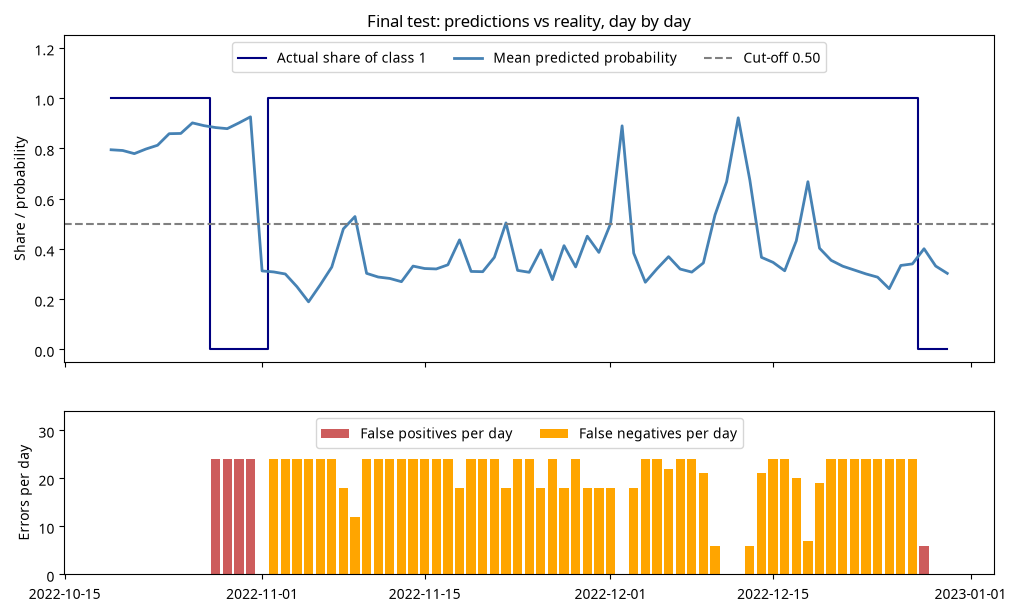

In [66]:
errors["date"] = errors["timestamp"].dt.floor("D")

daily = errors.groupby("date").agg(actual_share=("actual", "mean"), mean_probability=("probability", "mean"),
                                   false_positives=("false_positive", "sum"), false_negatives=("false_negative", "sum"))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].step(daily.index, daily["actual_share"], where="mid", color="navy", label="Actual share of class 1")
axes[0].plot(daily.index, daily["mean_probability"], color="steelblue", linewidth=2, label="Mean predicted probability")
axes[0].axhline(0.5, color="gray", linestyle="--", label="Cut-off 0.50")
axes[0].set_ylabel("Share / probability")
axes[0].set_title("Final test: predictions vs reality, day by day")
axes[0].set_ylim(-0.05, 1.25)
axes[0].legend(loc="upper center", ncol=3)

axes[1].bar(daily.index, daily["false_positives"], color="indianred", label="False positives per day")
axes[1].bar(daily.index, daily["false_negatives"], color="orange", label="False negatives per day")
axes[1].set_ylabel("Errors per day")
axes[1].set_ylim(0, 34)
axes[1].legend(loc="upper center", ncol=2)

plt.savefig("../04_Figures/12_error_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

In [67]:
daily[(daily["false_positives"] > 0) | (daily["false_negatives"] > 0)].round(2)

,actual_share,mean_probability,false_positives,false_negatives
date,,,,
2022-10-28,0.0,0.88,24,0
2022-10-29,0.0,0.88,24,0
2022-10-30,0.0,0.90,24,0
2022-10-31,0.0,0.93,24,0
2022-11-02,1.0,0.31,0,24
2022-11-03,1.0,0.30,0,24
2022-11-04,1.0,0.25,0,24
2022-11-05,1.0,0.19,0,24
2022-11-06,1.0,0.26,0,24


### 21.3 Do errors change over time?

In [68]:
errors_by_month = errors.groupby(errors["timestamp"].dt.month).agg(
    rows=("actual", "size"), share_class_1=("actual", "mean"),
    false_positives=("false_positive", "sum"), false_negatives=("false_negative", "sum"))
errors_by_month["share_class_1"] = errors_by_month["share_class_1"].round(2)
errors_by_month

,rows,share_class_1,false_positives,false_negatives
timestamp,,,,
10,308,0.69,96,0
11,720,0.97,0,642
12,720,0.90,6,494


### 21.4 Are particular conditions harder? Missing sensor data

In [69]:
errors["groundwater_missing"] = X_test["gw_lvl_site2_anomaly_score"].isnull().values

errors.groupby("groundwater_missing").agg(
    rows=("actual", "size"),
    share_actually_class_1=("actual", "mean"),
    share_predicted_class_1=("predicted", "mean"),
    false_positives=("false_positive", "sum"),
    false_negatives=("false_negative", "sum")).round(3)

,rows,share_actually_class_1,share_predicted_class_1,false_positives,false_negatives
groundwater_missing,,,,,
False,308,0.688,1.000,96,0
True,1440,0.933,0.149,6,1136


When the groundwater sensor is down, the imputer fills the gap with the **training median**. What does that value look like to the model, which gives the groundwater score a large positive weight?

In [70]:
gw_train = X_train["gw_lvl_site2_anomaly_score"]

print("Groundwater-level score in TRAINING: median =", round(gw_train.median(), 1),
      "| mean =", round(gw_train.mean(), 1), "| standard deviation =", round(gw_train.std(), 1))
print("After scaling, the median used to fill gaps is", round((gw_train.median() - gw_train.mean()) / gw_train.std(), 2),
      "standard deviations from the mean")

Groundwater-level score in TRAINING: median = 16.8 | mean = 25.2 | standard deviation = 22.6
After scaling, the median used to fill gaps is -0.37 standard deviations from the mean


### 21.5 Median score values by outcome (`NaN` = no value was measured)

In [71]:
errors.groupby("outcome")[top_features].median().T.round(2)

outcome,False negative,False positive,True negative,True positive
gw_lvl_site2_anomaly_score,NaN,95.80,NaN,76.64
gw_temp_site2_anomaly_score,NaN,24.59,NaN,24.59
temp_site1_anomaly_score,5.68,3.90,5.18,6.65
sfc_temp_site1_anomaly_score,5.86,4.66,6.15,6.33
326416_ws_vigor,1.37,0.00,1.37,0.00
279805_ws_vigor,0.00,0.00,0.00,0.00


### What the error analysis shows

**Two completely different failure modes in the test period:**

1. **While the groundwater sensors work (19–31 October, 308 hours):** the model predicts class 1 for *every* hour. That is right for most of them, but wrong for **28–31 October**, a class-0 stretch: **96 false positives**, with a predicted probability of 0.88–0.93. In those four days the groundwater-level score is very high (median 95.8) — and the model has learned that a high groundwater-level score means class 1.
2. **While the groundwater sensors are down (1 November – 30 December, 1,440 hours):** the model predicts class 1 for only **14.9%** of hours although **93.3%** of them truly are class 1. This produces **1,136 false negatives** (642 in November, 494 in December), with a typical predicted probability of 0.3.

**Why does an outage push the model towards class 0?** The imputer fills a missing groundwater score with the training median (16.8), which is **0.37 standard deviations below the training mean** (25.2). The model gives the groundwater scores large positive weights (Section 22). So for every hour of the two-month outage, the model sees a slightly "below-average" groundwater score and nudges its answer towards class 0. This is an example of how filling gaps with a typical value can quietly mislead a model.

**The 90 true negatives are "right for the wrong reason":** they are 1 November (24 hours) and 28–30 December (66 hours) — hours inside the outage where the model was predicting class 0 for almost everything.

**Do errors change over time?** Completely: October has 96 false positives and no false negatives; November has no false positives and 642 false negatives; December has 6 and 494.

**Are some conditions harder?** Yes — periods when a sensor the model relies on is **missing**, and periods when a score behaves differently from training (the high groundwater scores on 28–31 October).

**What it means:** the mistakes are not random noise. They follow *which sensors are available* and *how their scores relate to the label in each period*. We cannot say what physically happened in the network on those days — that would need raw data and domain experts.

---
# Section 22 — Feature Importance / Interpretation

**What we learn here:** which inputs the final model relies on.  **Why:** to check the model makes sense and to see what it is using.

We use **permutation importance**: *shuffle one feature's values and see how much the model gets worse.* If the score drops, the model was using that feature. We measure the drop in **ROC-AUC** (a threshold-free score, so small effects are not hidden).

We apply it to the final model on the test period purely for interpretation — nothing is changed afterwards.

In [72]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42)

importance = pd.DataFrame({"Feature": feature_columns, "Drop in ROC-AUC": perm.importances_mean,
                           "Std": perm.importances_std}).sort_values("Drop in ROC-AUC", ascending=False)
importance.head(10).round(4)

,Feature,Drop in ROC-AUC,Std
14,temp_site1_anomaly_score,0.0180,0.0070
13,326416_ws_vigor,0.0177,0.0054
12,326417_ws_temp,0.0174,0.0095
6,279805_ws_vigor,0.0076,0.0044
2,4408411600_kW,0.0010,0.0011
1,4700008966_power_hour,0.0005,0.0019
4,4608927500_kvar_hour,0.0004,0.0007
0,4700008966_kW,0.0003,0.0017
18,hour,0.0002,0.0009
7,279804_ws_level,0.0001,0.0004


In [73]:
importance.tail(5).round(4)       # the features whose shuffling made the model BETTER

,Feature,Drop in ROC-AUC,Std
19,day_of_week,-0.0033,0.0069
17,gw_temp_site2_anomaly_score,-0.0095,0.0051
11,279831_ws_temp,-0.0140,0.0035
15,sfc_temp_site1_anomaly_score,-0.0188,0.0048
16,gw_lvl_site2_anomaly_score,-0.1921,0.0137


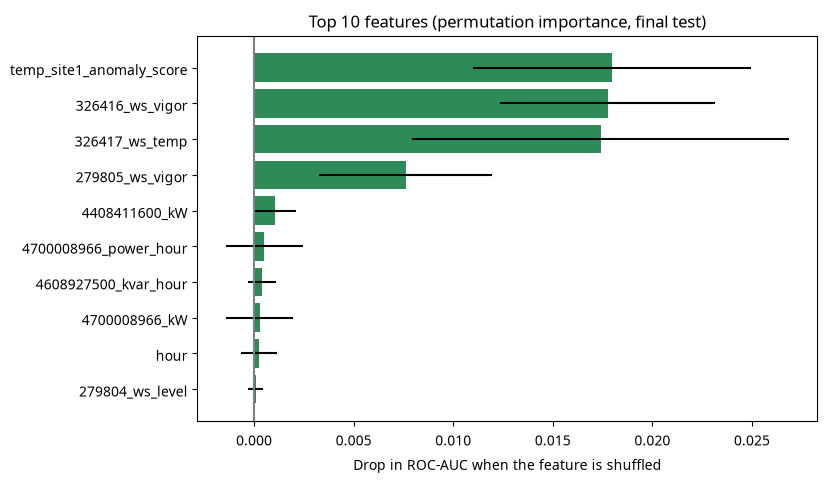

In [74]:
top10 = importance.head(10).sort_values("Drop in ROC-AUC")

plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Drop in ROC-AUC"], xerr=top10["Std"], color="seagreen")
plt.axvline(0, color="gray")
plt.title("Top 10 features (permutation importance, final test)")
plt.xlabel("Drop in ROC-AUC when the feature is shuffled")
plt.savefig("../04_Figures/13_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

In [75]:
importance[importance["Feature"].isin(["hour", "day_of_week"])].round(4)

,Feature,Drop in ROC-AUC,Std
18,hour,0.0002,0.0009
19,day_of_week,-0.0033,0.0069


### Logistic Regression coefficients
Because the final model is a Logistic Regression, we can also read its **coefficients** (on the standardised features): a positive number pushes the prediction towards class 1, a negative number towards class 0. These are the eight largest in absolute size. Names starting with `missingindicator_` are the "was missing" flags from Section 10.

In [76]:
lr_step = final_model[-1]                              # the Logistic Regression inside the pipeline
step_names = final_model[:-1].get_feature_names_out()   # names after imputation and scaling

coefficients = pd.DataFrame({"Feature": step_names, "Coefficient": lr_step.coef_[0]})
coefficients["Size"] = coefficients["Coefficient"].abs()
coefficients.sort_values("Size", ascending=False).head(8)[["Feature", "Coefficient"]].round(3)

,Feature,Coefficient
16,gw_lvl_site2_anomaly_score,0.811
17,gw_temp_site2_anomaly_score,0.582
25,missingindicator_279623_ws_vigor,0.367
24,missingindicator_279625_ws_temp,0.367
6,279805_ws_vigor,0.313
27,missingindicator_279831_ws_temp,-0.310
14,temp_site1_anomaly_score,0.279
10,319235_ws_temp,0.271


### Do the relationships stay the same over time?
Permutation importance only tells us what the model *uses*. Let us also check whether each score's relationship with the label stays the same in the three periods. We use the simple correlation between a score and the 0/1 label, calculated separately for each period (`NaN` = the score has no variation in that period).

In [77]:
with np.errstate(invalid="ignore", divide="ignore"):      # hides a harmless warning for scores that never change
    drift_table = pd.DataFrame({
        "Training": X_train[score_columns].corrwith(y_train),
        "Validation": X_val[score_columns].corrwith(y_val),
        "Final test": X_test[score_columns].corrwith(y_test),
    }).round(2)

drift_table.loc[["gw_lvl_site2_anomaly_score", "gw_temp_site2_anomaly_score", "temp_site1_anomaly_score",
                 "sfc_temp_site1_anomaly_score", "326416_ws_vigor", "4700008966_kW"]]

,Training,Validation,Final test
gw_lvl_site2_anomaly_score,0.36,-0.06,-0.84
gw_temp_site2_anomaly_score,0.19,-0.24,NaN
temp_site1_anomaly_score,0.24,0.06,0.09
sfc_temp_site1_anomaly_score,0.23,0.05,0.00
326416_ws_vigor,0.05,0.05,0.09
4700008966_kW,0.08,0.05,0.05


**What we see:**
- **Positive importance** (the model uses the feature in a way that helps): only a few features, and all small — `temp_site1` (0.018), `326416_ws_vigor` (0.018), `326417_ws_temp` (0.017) and `279805_ws_vigor` (0.008). Almost everything else is about 0.
- **Negative importance** (shuffling the feature makes the model *better*): `gw_lvl_site2` (**−0.192**), `sfc_temp_site1` (−0.019), `279831_ws_temp` (−0.014), `gw_temp_site2` (−0.010) and `day_of_week` (−0.003). `hour` is about 0.
- **Coefficients:** the two largest are the groundwater scores — `gw_lvl_site2` (+0.81) and `gw_temp_site2` (+0.58): the model leans on them most, and a high value pushes towards class 1.
- **Over time** (correlation with the label, separately per period): the groundwater-level score goes from **+0.36 in training** to −0.06 in validation to **−0.84 in the final test** (only in the 308 hours where it was measured). The groundwater-temperature score goes from +0.19 to −0.24, and has no variation where measured in the test period. The two temperature scores stay weakly positive but fade: `temp_site1` goes 0.24 → 0.06 → 0.09 and `sfc_temp_site1` goes 0.23 → 0.05 → 0.00.

**What it means in plain language:**
- The model's strongest-weighted features, the **groundwater scores**, **change direction** between periods. In training a high score went with class 1; in the final test a high score went with class 0. A model that trusts such a feature is guaranteed to be wrong later — which is why shuffling `gw_lvl_site2` actually *improves* the test ROC-AUC.
- The groundwater scores were also the very features that are **missing for 82% of the test period**.
- **`hour` and `day_of_week` do not help** (as EDA suggested). We do not remove them *now* — changing the model after seeing test results would mean tuning to the test set. Removing them is a sensible experiment for a future run.

⚠️ Importance means "useful for prediction in this period", **not** "causes leaks". The test-period correlation for the groundwater level rests on only 308 hours (about 12 days with two label stretches) — it is a warning sign, not a precise estimate.

---
# Section 23 — Model Reality Check

**What we learn here:** how good the model *really* is.  **Why:** headline metrics can flatter a model when one class dominates.

We add two metrics that look at **both classes**:
- **Specificity** = TN / (TN + FP): of the real class-0 hours, how many did we correctly call 0? (Recall for class 0.)
- **Balanced accuracy** = (recall + specificity) / 2: accuracy that is not dominated by the bigger class.

In [78]:
from sklearn.metrics import balanced_accuracy_score

reality = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "Specificity", "Balanced accuracy", "F1", "ROC-AUC", "PR-AUC"])

for name in test_pred:
    pred = test_pred[name]
    proba = test_proba[name]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    reality.loc[name] = [accuracy_score(y_test, pred), precision_score(y_test, pred, zero_division=0),
                         recall_score(y_test, pred, zero_division=0), tn / (tn + fp),
                         balanced_accuracy_score(y_test, pred), f1_score(y_test, pred),
                         roc_auc_score(y_test, proba), average_precision_score(y_test, proba)]

print("Share of class 1 in the test period (= PR-AUC 'no skill' level):", round(y_test.mean(), 4))
reality.round(4)

Share of class 1 in the test period (= PR-AUC 'no skill' level): 0.8902


,Accuracy,Precision,Recall,Specificity,Balanced accuracy,F1,ROC-AUC,PR-AUC
Baseline (most frequent),0.8902,0.8902,1.0000,0.0000,0.5000,0.9419,0.5000,0.8902
Tuned Logistic Regression (final),0.2918,0.8046,0.2699,0.4688,0.3693,0.4042,0.3101,0.8228


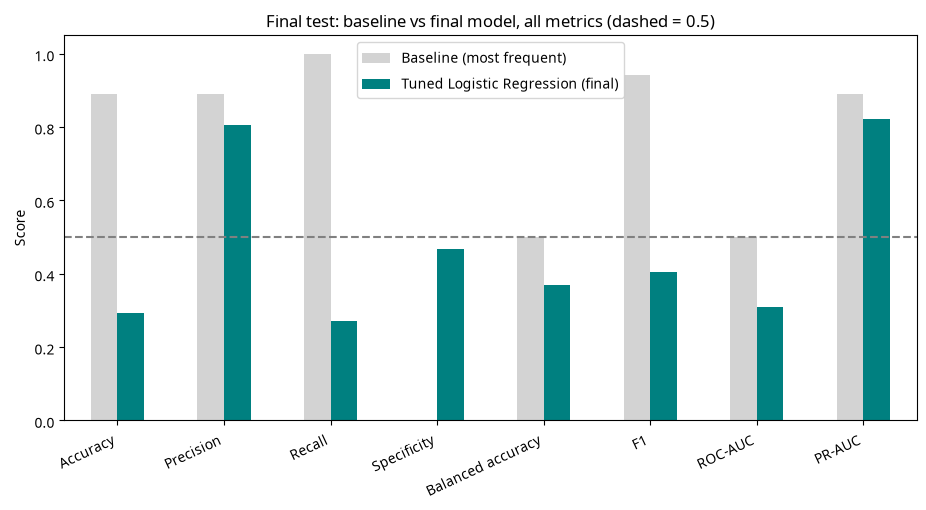

In [79]:
reality.T.plot(kind="bar", figsize=(11, 5), color=["lightgray", "teal"])
plt.axhline(0.5, color="gray", linestyle="--")
plt.title("Final test: baseline vs final model, all metrics (dashed = 0.5)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.savefig("../04_Figures/14_reality_check.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see (final test):**

| | Accuracy | Recall | Specificity | Balanced accuracy | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|---|
| Baseline | 0.890 | 1.000 | 0.000 | 0.500 | 0.942 | 0.500 | 0.890 |
| Final model | 0.292 | 0.270 | 0.469 | 0.369 | 0.404 | 0.310 | 0.823 |

The share of class 1 (the PR-AUC "no skill" level) is 0.890.

### What the model does reasonably
Honestly, very little. It identifies 90 of the 192 class-0 hours (specificity 0.469, better than the baseline's 0), and precision is 0.805 — but, as Section 21 shows, the true negatives are largely an accident of a sensor outage, and its balanced accuracy (0.369) is **below** the baseline's 0.5.

### Where it is weak
- It **misses 73%** of class-1 hours (recall 0.27; 1,136 false negatives).
- **ROC-AUC 0.31** is below chance: it ranks hours in the wrong direction. PR-AUC is below its no-skill level.
- Its accuracy is **0.29 against 0.89** for doing nothing.
- It is confidently wrong on whole stretches (probability about 0.9 on the four false-alarm days).
- It depends on sensors (groundwater) whose relationship with the label reverses over time and which are **offline for 82% of the test period**.
- The evidence is thin: the test contains 192 class-0 hours (8 days) and the whole year contains only about 8 leak periods.

### What the dataset actually supports
With the time order correct, **these anomaly scores, used this way, do not allow reliable classification of later hours** into `fault_d7 = 0/1`. The best "model" on this data is the do-nothing baseline. This is **not** a leak detector of any kind, it says nothing about real-time use, and it says nothing about how early a leak could be flagged.

*Possible reasons (hypotheses, not findings):* the label is defined from **event dates**, not from sensor behaviour; the scores come from general-purpose anomaly detectors; sensors are offline for long stretches; the window includes days *after* an event; and there are very few events.

---
# Section 24 — Risk Analysis

Practical risks that could make this project's results misleading, and how we handled them:

| Risk | Why it matters | What we did / what remains |
|---|---|---|
| **Data leakage** | Random splits give fake-good scores (Section 8: ROC-AUC 1.0 vs 0.61). A *timestamp* mistake can also leak: wrongly parsed dates shuffle time (Section 3: 68 vs 16 label changes) | Corrected timestamps, chronological split, preprocessing learned on training only, `TimeSeriesSplit` with a gap, no neighbour-row features, test used once. *Remaining:* the label itself uses both sides of an event. |
| **Temporal dependence** | Only about **8 leak periods** exist in the year, so 8,737 rows are far fewer independent cases | Time-aware validation. *Remaining:* every score is rough. |
| **Class imbalance** | Class 1 is the majority (73.6%, and 89.0% in the test period), so accuracy, recall and F1 look good for a useless rule | Baseline row everywhere, ROC-AUC as the selection metric, specificity and balanced accuracy. |
| **False positives** | 102 false alarms, 96 of them in one four-day stretch | Reported openly; a real system would need a plan for alert fatigue. |
| **False negatives** | **1,136** missed class-1 hours (73% of them) | Reported openly; recall is never read alone. |
| **Target definition** | `fault_d7` is a symmetric ±7-day window; a 0 is not proof of "no leak"; the label comes from event dates | Called "leak-proximity", not leak detection. |
| **Drift and sensor outages** | Which sensors work changes between periods (groundwater offline for 82% of the test period); the strongest feature reversed its relationship with the label | Shown in Sections 9, 21 and 22; filling gaps with the median hides outages from the model. |
| **Limited coverage** | One year, one anonymised network, 192 class-0 hours in the test period | No claims beyond this dataset. |
| **Generalisation to other networks** | Sensors, pipes and climate differ everywhere | Not tested; would need other networks and years. |
| **Data documentation errors** | The documented timestamp format was wrong for days 1–12 | Always verify documentation against the data. |

---
# Section 25 — Limitations

What this project **cannot** prove:

- **It is a dataset-based classification experiment.** It measures how well published anomaly scores match a published label — nothing more.
- **`fault_d7` is the dataset's own proximity window** (about ±7 days around recorded leak events, before *and* after). It is not "a leak is happening now", and a 0 does not prove that no leak exists.
- **It is not proof of real-time leak detection** or early warning. The label includes days after an event, and we never measure how early (if at all) a leak could be flagged.
- **Its results are negative:** on correctly ordered data the machine-learning models did not beat the do-nothing baseline. That says something about *these scores, this label and this one year* — it does not prove that no leak-detection approach could work.
- **Results may not generalise** to another water network, another year, other sensors or another climate. The data covers one year of one anonymised zone.
- **The anomaly scores are published, not rebuilt.** We cannot check from this file whether each score used only past data, or whether the choice of published scores was influenced by the labels.
- **Row-level metrics overstate certainty.** Neighbouring hours are near-copies; only about 8 leak periods exist, and the final test contains only 8 class-0 days.
- **The timestamp format had to be inferred.** The rule "first number ≤ 12 means month" makes the whole file perfectly chronological with labels matching the documented ±7-day window, but it is our reconstruction; the dataset authors should confirm it.
- **Predictive importance is not causation.**
- **We used a fixed cut-off of 0.50** and did not study alert costs or other cut-offs.
- **Production use would need much more:** independent periods and networks, handling of sensor outages, event-level evaluation (lead time, alert burden), a genuinely forward-looking target and real operational data. This notebook is a learning exercise, not a monitoring system.

---
# Section 26 — Final Conclusion

### What we learned from the data
The timestamps are stored in **mixed formats** (days 1–12 month-first, days 13–31 day-first). Parsed as documented, the clock jumps backwards and the labels look fragmented; parsed correctly, the file is perfectly chronological and the labels form **only 17 blocks**, with the shortest class-1 block exactly 15 days — the documented ±7-day window. There are only about **8 leak periods** in the year. The 18 anomaly scores are mostly zero with rare spikes, correlate only weakly with the target (at most 0.32), and several sensors are offline for weeks or months — a different set in each period.

### What the target represents
`fault_d7 = 1` means "within about ±7 days of a recorded leak event" (before or after); `0` means no recorded event nearby. It is a **leak-proximity** label, not a live leak indicator. Class 1 is the **majority** (73.6% overall, 89.0% in the final test period).

### Models tested
A baseline ("always predict the most common class"), Logistic Regression, Random Forest and HistGradientBoosting, plus a small `GridSearchCV` on Logistic Regression (8 combinations), all validated with `TimeSeriesSplit` (5 folds, 14-day gap).

### Which model performed best
In cross-validation the **do-nothing baseline beat every ML model on all six metrics** (ROC-AUC 0.500 vs 0.279–0.385). The best ML model by the rule fixed in advance (ROC-AUC) was Logistic Regression, which tuning improved only to 0.406 — still below 0.5.

### Final test results (untouched, used once)
| | Accuracy | Precision | Recall | Specificity | Balanced acc. | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|---|---|
| **Baseline** | **0.890** | **0.890** | **1.000** | 0.000 | **0.500** | **0.942** | **0.500** | **0.890** |
| Tuned Logistic Regression | 0.292 | 0.805 | 0.270 | 0.469 | 0.369 | 0.404 | 0.310 | 0.823 |

Confusion matrix of the ML model: 90 TN, 102 FP, 1,136 FN, 420 TP.

### Important errors
**1,136 false negatives**, all while the groundwater sensors were offline (the model predicted class 1 for only 15% of those hours although 93% were class 1), and **96 false positives** in four consecutive days in October when the groundwater score was very high but the label was 0.

### Most useful features
None reliably. The groundwater scores carry the largest weights, but their relationship with the label **reverses** over time (correlation +0.36 in training, −0.84 in the final test), so shuffling them *improves* the test ROC-AUC. The temperature scores are weakly positive but fade over time. Hour and day of week do not help.

### Major risks and limitations
Timestamp errors in the source documentation, only about 8 leak periods, strong class imbalance in favour of class 1, sensor outages and drift, a label defined from event dates, one year of one anonymised network, and only 8 class-0 days in the test period.

### Honest bottom line
With the time order correct, these published anomaly scores **do not support reliable classification of later hours** into `fault_d7 = 0/1`: the machine-learning models are no better than — and on the final test far worse than — always predicting the most common class. This is **not** a leak detector and does not support real-time use. The value of the project is in the workflow and the lessons below.

### The overall workflow
**Understand → Explore → Prepare → Prevent Leakage → Split → Train → Evaluate → Tune → Interpret → Conclude.**

The biggest lessons are not about the algorithm: **(1)** check that a time series is in order *before* you sort it — a wrongly parsed date silently ruins every chronological step; **(2)** split by time, never randomly (ROC-AUC 1.0 vs 0.61 on the same model); **(3)** always put a baseline next to the model, and never judge a classifier by accuracy, recall or F1 alone when one class dominates; **(4)** watch for sensors that change or go offline between periods; and **(5)** touch the test set once and report what it says, even when it is not flattering.